## Analysis 1 - Revenue and growth Trend

**Business question** Is this business growing and is there a measurable seasonality in purchase behavior?

### Final findings 
This analysis evaluates monthly revenue trends using 20 complete months of data from the Olist marketplace (January 2017 to August 2018), excluding partial months to avoid distortion.

Revenue shows *strong upward growth*, increasing from **R$9.27M in 2017 to R$11.13M** in the first eight months of 2018 (+20.1%). While annualising 2018 suggests substantially higher growth, this projection assumes stable revenue across the remaining months , an assumption that may not hold given observed volatility and seasonality.

A pronounced revenue spike occurs in **November 2017 (R$1.6M, +55% MoM)**, consistent with Black Friday effects, followed by a **sharp contraction in December (-34%)**, indicating post-promotion demand pull-forward rather than sustained growth.

Contrary to typical Northern Hemisphere retail patterns, peak revenue months are concentrated mid-year (May–August). However, interpretation is constrained by incomplete late-2018 data, limiting direct month-to-month comparability.

Growth dynamics shift over time: early 2017 exhibits hypergrowth **(up to +85% MoM)**, while 2018 stabilises to low single-digit growth, suggesting a transition from rapid expansion to a more mature revenue phase.

Overall, the platform demonstrates strong growth with emerging signs of maturation, event-driven revenue spikes, and locally specific seasonal patterns.




In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
master = pd.read_csv('../data/processed/master.csv',
                     parse_dates=['order_purchase_timestamp',
                                   'order_delivered_customer_date', 'order_estimated_delivery_date', ])
rfm_base = pd.read_csv('../data/processed/rfm_base.csv')

COLOUR_PRIMARY = '#14213d'
COLOUR_ACCENT =  '#415a77'
COLOUR_HIGHLIGHT = '#fb5607'
COLOUR_EMPHASIS = '#d00000'

In [2]:
master.shape


(113425, 29)

In [3]:
rfm_base.shape

(96136, 10)

In [4]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'product_id', 'seller_id', 'price', 'freight_value', 'review_score',
       'review_comment_message', 'product_category_name_english',
       'customer_unique_id', 'customer_city', 'customer_state',
       'payment_value', 'payment_type', 'payment_installments',
       'payment_count', 'seller_state', 'order_month', 'order_yeah',
       'order_dayofweek', 'delivery_delay_days', 'total_item_value',
       'was_late'],
      dtype='str')

In [5]:
[col for col in master.columns if 'payment' in col.lower()]

['payment_value', 'payment_type', 'payment_installments', 'payment_count']

In [6]:
print(master['order_month'])

0         2017-10
1         2018-07
2         2018-08
3         2017-11
4         2018-02
           ...   
113420    2018-02
113421    2017-08
113422    2018-01
113423    2018-01
113424    2018-03
Name: order_month, Length: 113425, dtype: str


In [7]:
#trying to find out which months have 27+ days
days_per_month = (
    master
    .groupby('order_month')['order_purchase_timestamp']
    .apply(lambda x: x.dt.day.nunique())
    .reset_index()
    .rename(columns={'order_purchase_timestamp' : 'days_with_orders'})

)

print(days_per_month.to_string(index=False))

order_month  days_with_orders
    2016-09                 4
    2016-10                10
    2016-12                 1
    2017-01                27
    2017-02                28
    2017-03                31
    2017-04                30
    2017-05                31
    2017-06                30
    2017-07                31
    2017-08                31
    2017-09                30
    2017-10                31
    2017-11                30
    2017-12                31
    2018-01                31
    2018-02                28
    2018-03                31
    2018-04                30
    2018-05                31
    2018-06                30
    2018-07                31
    2018-08                31
    2018-09                11
    2018-10                 4


## tO NOTE: 
from 2017-01 till 2018-08 we have the days that have 27-31 days which are full months. 2016 could be that they just started out and business is still fresh. We cannot use the ones with less orders. 
The real clean data runs from 2017-01 to 2018-08

In [8]:
complete_months = days_per_month[
    days_per_month['days_with_orders'] >= 27
]['order_month']

print(f"Complete months: {len(complete_months)}")
print(complete_months.tolist())

Complete months: 20
['2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07', '2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08']


In [9]:
monthly_revenue = (
    master[master['order_month'].isin(complete_months)]
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue['mom_growth_pct'] = (
    monthly_revenue['payment_value'].pct_change() * 100
)

print(f" Min: {monthly_revenue['mom_growth_pct'].min():.1f}%")
print(f" Max: {monthly_revenue['mom_growth_pct'].max():.1f}%")

print(monthly_revenue[['order_month', 'payment_value', 'mom_growth_pct']].to_string(index=False))

 Min: -33.9%
 Max: 85.0%
order_month  payment_value  mom_growth_pct
    2017-01      189015.66             NaN
    2017-02      349701.93       85.012147
    2017-03      544738.23       55.772154
    2017-04      510891.55       -6.213384
    2017-05      731017.09       43.086549
    2017-06      608891.38      -16.706273
    2017-07      744599.53       22.287744
    2017-08      876129.37       17.664508
    2017-09     1023095.49       16.774477
    2017-10     1031505.53        0.822019
    2017-11     1599444.18       55.059196
    2017-12     1057582.34      -33.878134
    2018-01     1415348.54       33.828685
    2018-02     1311260.71       -7.354219
    2018-03     1480045.50       12.871947
    2018-04     1497843.94        1.202560
    2018-05     1511113.00        0.885877
    2018-06     1298685.81      -14.057664
    2018-07     1359421.48        4.676702
    2018-08     1248837.93       -8.134604


### DATA COVERAGE NOTE

The dataset spans from September 2016 to October 2018 but only contains complete montly data from January 2017 to August 2018 ( which are 20 full months)

-Sep- Dec 2016: Platform launch period

TO AVOID DISTORTION FROM INCOMPLETE PERIODS . THE TREND ANALYSIS USES 20 COMPLETE MONTHS 


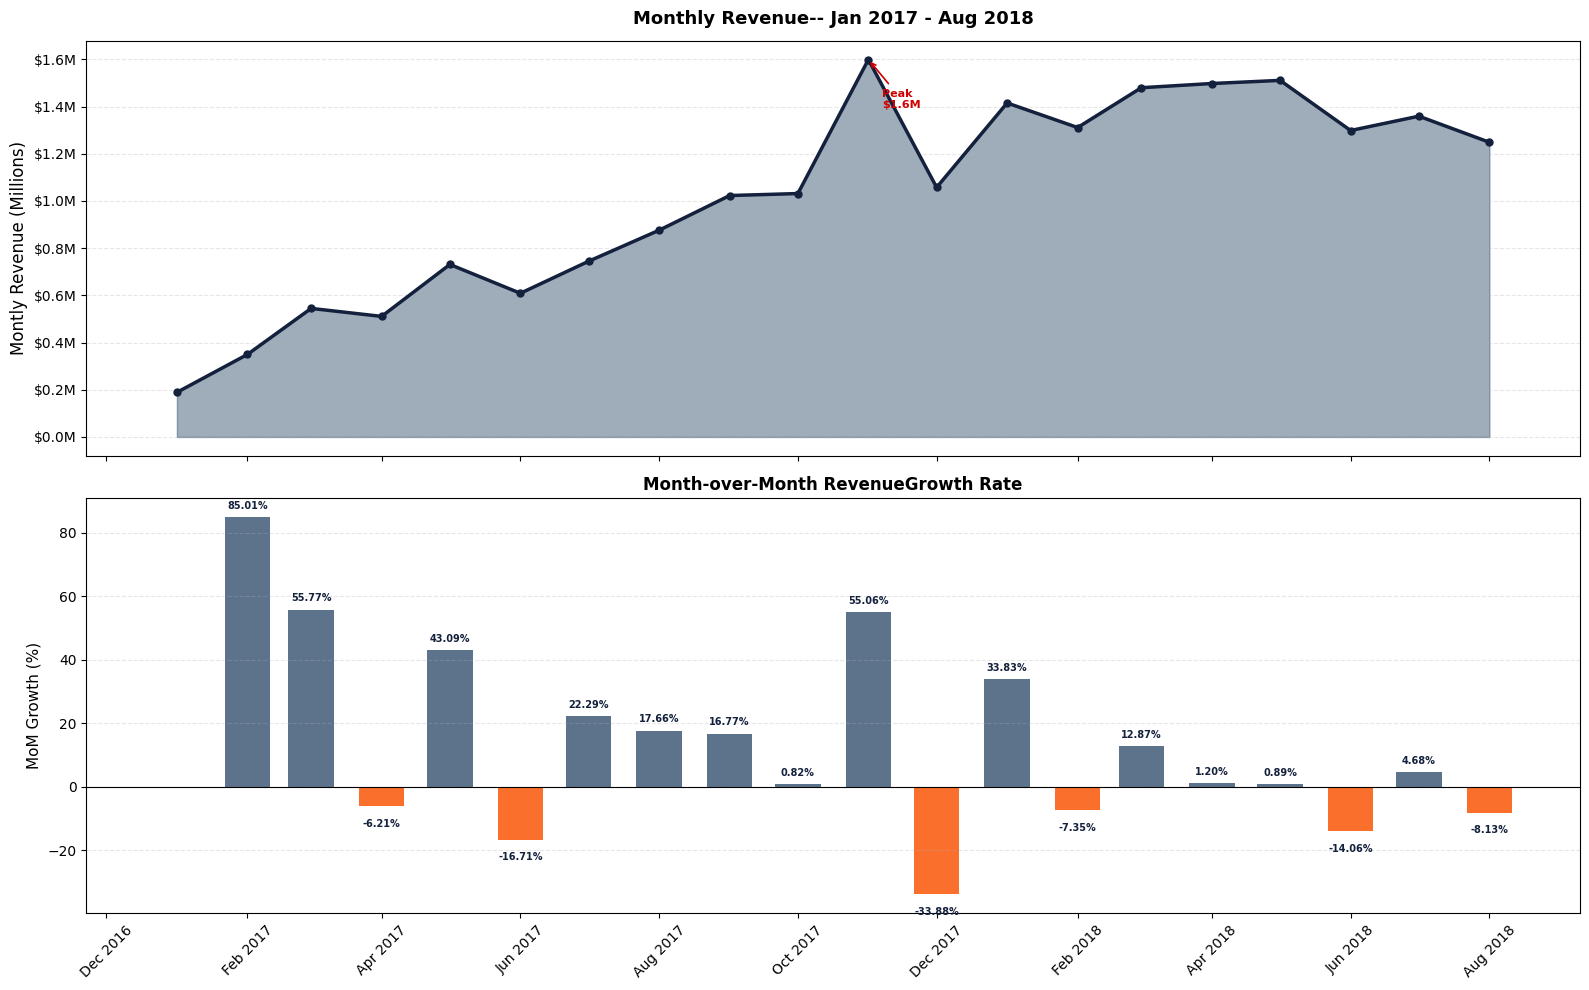

In [10]:
fig, (ax1 , ax2) = plt.subplots(
    2,1,
    figsize=(16,10),
    sharex=True,
  
)

revenue_millions = monthly_revenue['payment_value'] / 1e6
monthly_revenue['order_month'] = pd.to_datetime(monthly_revenue['order_month'])
month_dt = monthly_revenue['order_month']

ax1.plot(
    month_dt, revenue_millions,
    color=COLOUR_PRIMARY, linewidth=2.5,
    marker='o', markersize=5, zorder=3
)

ax1.fill_between(month_dt, revenue_millions, alpha=0.5, color=COLOUR_ACCENT)

peak_ann = monthly_revenue['payment_value'].idxmax()
peak_x = month_dt[peak_ann]
peak_y = revenue_millions[peak_ann]

ax1.annotate(
    f"Peak\n${peak_y:.1f}M",
    xy=(peak_x,peak_y),
    xytext=(10,-35),
    textcoords='offset points',
    fontsize=8, color=COLOUR_EMPHASIS, fontweight='semibold',
    arrowprops=dict(arrowstyle='->' , color=COLOUR_EMPHASIS, lw=1.2)
)

ax1.set_ylabel('Montly Revenue (Millions)', fontsize=12)
ax1.set_title(
    'Monthly Revenue-- '
    'Jan 2017 - Aug 2018',
    fontsize=13, fontweight='bold', pad=12
)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.1f}M') 
)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

growth_data = monthly_revenue['mom_growth_pct'].fillna(0)
bar_colors = [
    COLOUR_ACCENT if x>= 0 else COLOUR_HIGHLIGHT for x in growth_data
]

ax2.bar(month_dt, growth_data, color=bar_colors, width=20 , alpha=0.85)
ax2.axhline(y=0 ,color='black', linewidth=0.8)

for x , y in zip(month_dt, growth_data):
    if y != 0 : ax2.text (
        x,y + (2 if y >= 0 else -4 ),
        f'{y:.2f}%',
        ha='center', va='bottom' if y >= 0 else'top',
        fontsize=7, color=COLOUR_PRIMARY, fontweight='semibold',
    )
        
ax2.set_ylabel('MoM Growth (%)', fontsize=11)
ax2.set_title('Month-over-Month RevenueGrowth Rate', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
##Checking the stats

master['order_year'] = master['order_purchase_timestamp'].dt.year

yearly_revenue = (
    master
    .groupby('order_year')['payment_value']
    .sum()
    .reset_index()
)
yearly_revenue = yearly_revenue[yearly_revenue['order_year'] != 2016]
yearly_revenue['yoy_growth_pct'] = (
    yearly_revenue['payment_value'].pct_change() * 100
)


print('Year over Year Revenue:')
print('='*50)

for _,row in yearly_revenue.iterrows():
    growth_str = (
        f"     (+ {row['yoy_growth_pct']:.1f}% YoY)"
        if not pd.isna(row['yoy_growth_pct'])
        else ''
    )
    print(f"   {int(row['order_year'])} : "
          f"${row['payment_value']:>12,.2f}{growth_str}")

Year over Year Revenue:
   2017 : $9,266,612.28
   2018 : $11,127,586.12     (+ 20.1% YoY)


In [12]:
master['month_of_year'] = master['order_purchase_timestamp'].dt.month
monthly_avg = (
    master
    .groupby('month_of_year')['payment_value']
    .sum()
    .reset_index()
)

months = {
    1:'Jan' , 2: 'Feb', 3: 'Mar' , 4: 'Apr' , 5:'May' , 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec', 
}

monthly_avg['month'] = monthly_avg['month_of_year'].map(months)

print(f"\nRevenue by Month of year")
print('-'*45)
for _, row in monthly_avg.iterrows():
    bar = '✔' * int(row['payment_value'] / monthly_avg['payment_value'].max() * 30)
                    
    print(f"   {row['month']}: {bar}   ${row['payment_value']:>12,.0f}")


Revenue by Month of year
---------------------------------------------
   Jan: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,604,364
   Feb: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,660,963
   Mar: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,024,784
   Apr: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,008,735
   May: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,242,130
   Jun: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,907,577
   Jul: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,104,021
   Aug: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,124,967
   Sep: ✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,027,924
   Oct: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,108,215
   Nov: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,599,444
   Dec: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,057,602


## Analysis 1 — Revenue Trend: Observations & Findings
 
---
 
### Data Coverage Note
 
The Olist dataset spans September 2016 to October 2018 but only
contains complete monthly data across two time windows:
 
- **2016 (Sep–Dec):** Platform launch period. Excluded from trend
  analysis — partial months with as few as 1 day of orders produce
  astronomically distorted growth rates (e.g. +963,000% MoM).
- **2017 (Jan–Dec):** Full year, 12 complete months. ✓
- **2018 (Jan–Aug):** 8 complete months before dataset truncation. ✓
- **2018 (Sep–Oct):** Excluded — dataset cut off mid-month.
 
**All revenue trend analysis uses 20 complete months (Jan 2017 – Aug 2018).**
 
---
 
### Finding 1 — Strong Year-over-Year Growth
 
Revenue grew from **R$9.27M in 2017 to R$11.13M in 2018 (+20.1% YoY)**.

 Note: Compared to 12 months for 2017, the 2018 statistic only includes 8 months (January through August). 2018 was tracking much higher on an annual basis; projecting the 8-month average forward yields a projected full-year 2018 revenue of around**R$16.7M** indicates actual YoY growth that is closer to **+80%**.

 *Implication: During the dataset period, the company was experiencing robust growth. Inventory planning and revenue-based goals should take the ongoing rising trend into consideration.*

 
### Finding 2 — Black Friday Spike (November 2017)
 
November 2017 recorded the **peak single-month revenue of R$1.6M**,
representing a **+55% spike** above October 2017.
 
This is followed by a sharp -34% correction in December 2017 —
consistent with post-promotional demand exhaustion seen across
most e-commerce markets globally.

*Important disclaimer: The dataset only includes one instance of November and December (2017 only; 2018 equivalents were reduced). Although this result is directionally correct, it cannot be verified as a consistent yearly pattern based only on this dataset.*
 
*Implication: Inventory, logistics capacity, and seller support,should be scaled up in October each year in preparation for the November demand surge.*
 
---
 
### Finding 3 — Mid-Year Strength, Not Classic Seasonality
 
Aggregating revenue by calendar month across both years reveals
**May, August, and July as the three highest-revenue months**
(R$2.24M, R$2.12M, and R$2.10M respectively).
 
In markets in the Northern Hemisphere, this may seem contradictory.
The busiest month for retail is usually December. Brazil's summer months are December through February, which could help to explain some patterns of consumer spending.
 
**Disclaimer on this finding:** September and October appear lower
(R$1.03M and R$1.11M) because they only contain 2017 data —
their 2018 equivalents were excluded due to truncation. Their
bars are not directly comparable to Jan–Aug which contain two
years of data summed.
 
*Implication: Month-of-year revenue patterns for this Brazilian marketplace differ from Northern Hemisphere norms. Marketing and promotional planning should be calibrated to local patterns.*
 
---
 
### Finding 4 — Growth Maturation Through 2018
 
Early 2017 showed explosive MoM growth rates (+85% in Feb 2017,
+55% in Mar 2017) consistent with a platform in early hypergrowth.
 
By 2018 MoM growth had moderated to single digits in most months
(+0.9% in May 2018, +1.2% in Apr 2018), suggesting the platform
was maturing and stabilising at a higher revenue base rather than
continuing to grow exponentially.
 
*Implication: The business appears to be transitioning from acquisition-driven growth to retention-driven growth — making customer lifetime value and churn prediction increasingly important analytical priorities (addressed in Notebooks 02 and 03).*
 
---
 
### Summary 

- Analysis period | Jan 2017 – Aug 2018 (20 months) |
- 2017 total revenue | R$9,266,612 |
- 2018 total revenue (8 months) | R$11,127,586 |
- YoY growth (comparable periods) | +20.1% |
- Peak month | November 2017 — R$1,599,444 |
- Highest MoM growth | February 2017 — +85.0% |
- Largest MoM decline | December 2017 — -33.9% |
- Strongest calendar month | May — R$2,242,130 (2 years summed) |
 
---
*Feeds into: Analysis 3 (Delivery Performance) where we test
whether delivery delays are statistically associated with
review score — a key driver of repeat purchase and revenue.*
"""

---
## Analysis 2 Customer Geography
---
### WHAT THIS ANALYSIS ANSWERS:

- Where are Olist's customers concentrated geographically?
- Are there states that are both high-volume AND high-value?
- Or do high-volume states have lower average order values?

### WHY THIS MATTERS FOR BUSINESS:
Geographic concentration is a risk as well as an opportunity. A local rival, a regional economic shock, or a logistical interruption in a state that accounts for 40% of income can have a disproportionately large influence on the business.

### Understanding geography also informs:
- Where to expand seller coverage (underserved high-demand states)
- Where delivery performance is weakest (Analysis 3)
- Where to focus marketing spend

In [13]:
orders_deduped = master.drop_duplicates(subset='order_id').copy()
print(f"item level: {len(master)}")
print(f"after deduped: {len(orders_deduped):}")
print(f"the difference {len(master) - len(orders_deduped)}")

geo_stats = (
    orders_deduped
    .groupby('customer_state')
    .agg(
        total_orders     = ('order_id' ,'count'),
        total_revenue      = ( 'payment_value', 'sum'),
        avg_order_value  = ('payment_value', 'mean'),
        unique_customers       =('customer_unique_id', 'nunique'),
        avg_review_score       = ('review_score', 'mean'),
    ).reset_index()
)

geo_stats['pct_orders'] = geo_stats['total_orders'] / geo_stats['total_orders'].sum() * 100
geo_stats['pct_revenue'] = geo_stats['total_revenue'] / geo_stats['total_revenue'].sum() * 100

geo_stats = geo_stats.sort_values('total_revenue', ascending=False).reset_index(drop=True)

print('TOP 10 STATES')
print(f"{'State':<8} {'Orders':>8} {'% Orders':>8} {'Revenue':>14} {'% Revenue':>11} {'Avg Order':>10}")
print('='*80)
for _, row in geo_stats.head(10).iterrows():
    print(f" {row['customer_state']:<6} {row['total_orders']:>8,}"
        f"{row['pct_orders']:>9.1f}%   $"
        f"{row['total_revenue']:>12,.0f} "
        f"{row['pct_revenue']:>10.1f}%  $"
        f"{row['avg_order_value']:>8,.0f}" )
    
        

item level: 113425
after deduped: 99441
the difference 13984
TOP 10 STATES
State      Orders % Orders        Revenue   % Revenue  Avg Order
 SP       41,746     42.0%   $   5,998,227       37.5%  $     144
 RJ       12,852     12.9%   $   2,144,380       13.4%  $     167
 MG       11,635     11.7%   $   1,872,257       11.7%  $     161
 RS        5,466      5.5%   $     890,899        5.6%  $     163
 PR        5,045      5.1%   $     811,156        5.1%  $     161
 SC        3,637      3.7%   $     623,086        3.9%  $     171
 BA        3,380      3.4%   $     616,646        3.9%  $     182
 DF        2,140      2.2%   $     355,141        2.2%  $     166
 GO        2,020      2.0%   $     350,092        2.2%  $     173
 ES        2,033      2.0%   $     325,968        2.0%  $     160


In [14]:
top5 = geo_stats.head(5)['pct_revenue'].sum()
top5_orders = geo_stats.head(5)['pct_orders'].sum()

print(f"Top 5 {top5:.1f}% of revenue")
print(f"Top 5 {top5_orders:.1f}% of orders")
print(f" Total states with orders : {len(geo_stats)}")


Top 5 73.2% of revenue
Top 5 77.2% of orders
 Total states with orders : 27


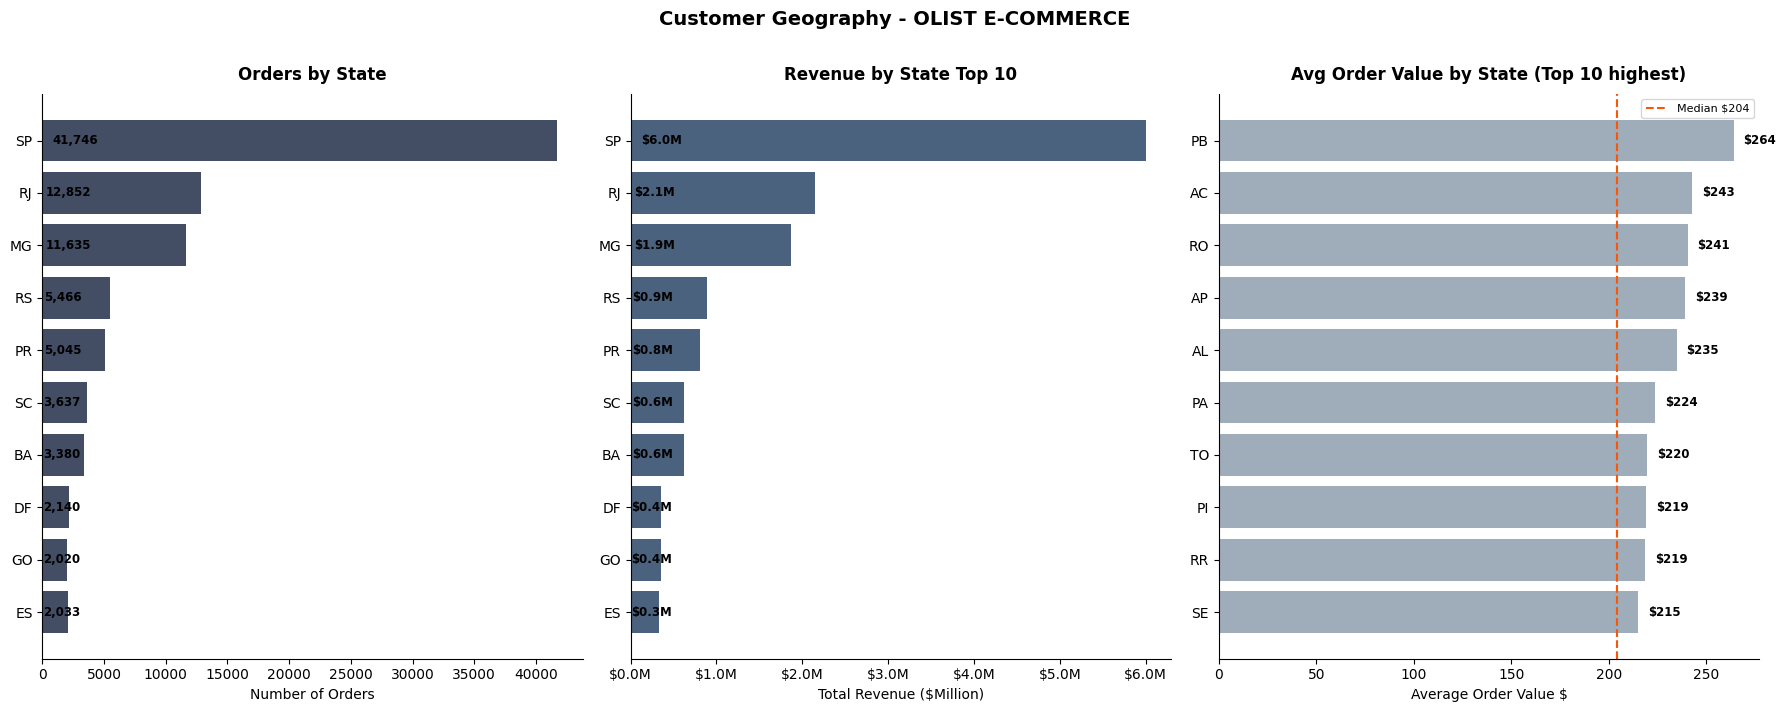

In [15]:
fig , axes = plt.subplots(
    1,3,
    figsize=(18,7)
)

top_n = 10
top_states = geo_stats.head(top_n).copy()

bar1 = axes[0].barh(
    top_states['customer_state'][::-1],
    top_states['total_orders'][::-1],
    color=COLOUR_PRIMARY,
    alpha=0.8,
)

for bar, val in zip(bar1, top_states['total_orders'][::-1]):
    axes[0].text(
        bar.get_width() * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', ha='left',
        fontsize=8.5, color='black', fontweight='bold'
    )
 
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Orders by State', fontweight='bold', pad=10)
axes[0].set_xlim(0, top_states['total_orders'].max() * 1.05)

bar2 = axes[1].barh(
    top_states['customer_state'][::-1],
    top_states['total_revenue'][::-1]/1e6,
    color=COLOUR_ACCENT,
    alpha=0.95

)

for bar, val in zip(bar2, top_states['total_revenue'][::-1]):
    axes[1].text(
        bar.get_width() * 0.02,
        bar.get_y() + bar.get_height()/2,
        f"${val/1e6:.1f}M",
        va='center', ha='left',
        fontsize=8.5 , color='black', fontweight='bold'
    )

axes[1].set_xlabel('Total Revenue ($Million)')
axes[1].set_title('Revenue by State Top 10', fontweight='bold', pad=10)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.1f}M')
)

aov_sorted = geo_stats.sort_values('avg_order_value', ascending=True).tail(top_n)
median_aov = geo_stats['avg_order_value'].median()
bar_colors = [
    COLOUR_ACCENT if v >= median_aov else COLOUR_PRIMARY
    for v in aov_sorted['avg_order_value']
]

bar3 = axes[2].barh(
    aov_sorted['customer_state'],
    aov_sorted['avg_order_value'],
    color=bar_colors,
    alpha=0.5
)

for bar, val in zip(bar3, aov_sorted['avg_order_value']):
    axes[2].text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f'${val:.0f}',
        va='center', ha='left',
        fontsize=8.5, color='black', fontweight='semibold'
    )
axes[2].axvline(
    color=COLOUR_HIGHLIGHT,
    x=median_aov,
    linewidth=1.5,
    linestyle='--',
    label=f"Median ${median_aov:.0f}"
)

axes[2].legend(fontsize=8)
axes[2].set_xlabel('Average Order Value $')
axes[2].set_title('Avg Order Value by State (Top 10 highest)', fontweight='bold', pad=10)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Customer Geography - OLIST E-COMMERCE',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()




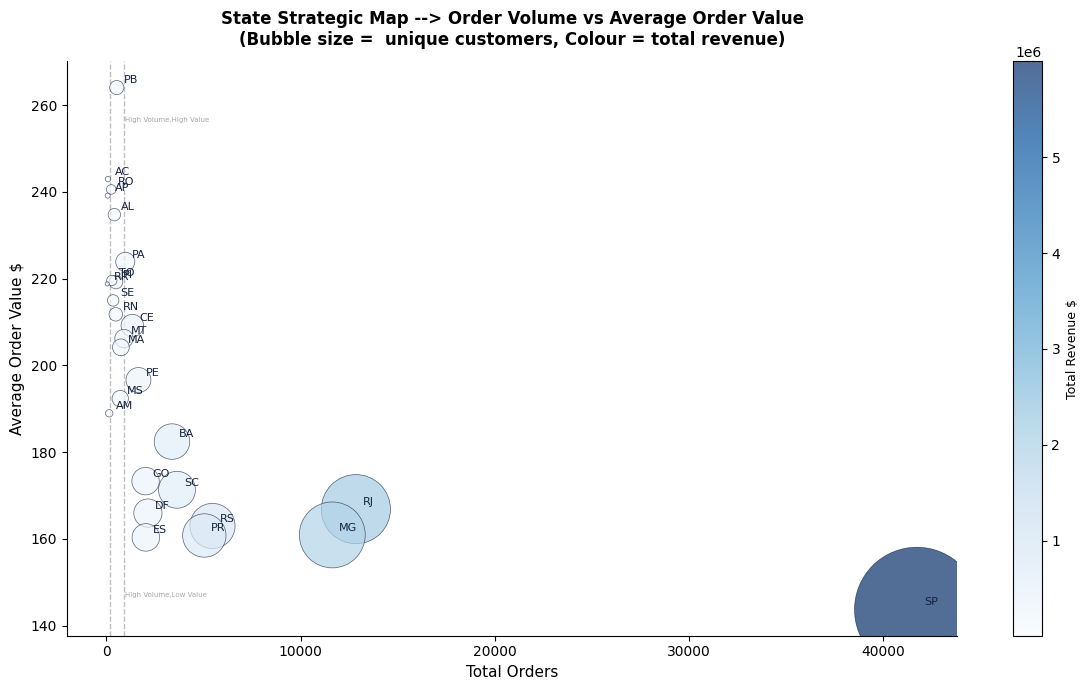

In [16]:
fig, ax = plt.subplots(figsize=(12,7))

scatter =  ax.scatter(
    geo_stats['total_orders'],
    geo_stats['avg_order_value'],
    s=geo_stats['unique_customers'] / 5,
    c=geo_stats['total_revenue'],
    cmap='Blues',
    alpha=0.7,
    edgecolors=COLOUR_PRIMARY,
    linewidths=0.5,
    zorder=3
)

for _, row in geo_stats.iterrows():
    ax.annotate(
        row['customer_state'],
        (row['total_orders'], row['avg_order_value']),
        textcoords='offset points',
        xytext=(5,3),
        fontsize=8,
        color=COLOUR_PRIMARY
    )

median_orders = geo_stats['total_orders'].median()
median_aov = geo_stats['avg_order_value'].median()

ax.axvline(x=median_orders, color='grey', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(x=median_aov, color='grey', linewidth=1, linestyle='--', alpha=0.5)

ax.text(median_orders * 1.05, geo_stats['avg_order_value'].max() * 0.97,
        'High Volume,High Value', fontsize=5,color='grey',alpha=0.7)

ax.text(median_orders * 1.05, geo_stats['avg_order_value'].min() * 1.02,
        'High Volume,Low Value', fontsize=5,color='grey',alpha=0.7)


cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Revenue $', fontsize=9)

ax.set_xlabel('Total Orders', fontsize=11)
ax.set_ylabel('Average Order Value $', fontsize=11)
ax.set_title(
    'State Strategic Map --> Order Volume vs Average Order Value\n'
    '(Bubble size =  unique customers, Colour = total revenue)',
    fontsize=12, fontweight='bold', pad=12
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Analysis 2 — Customer Geography: Observations & Findings
 
---
 
### Finding 1 — Severe Geographic Concentration
 
Revenue is heavily concentrated in a small number of states.
The top 5 states account for approximately **77.2% of all orders
and 73.2% of total revenue** from 27 states with any orders.
 
As the most populous state in Brazil and the hub of the country's e-commerce infrastructure, São Paulo (SP) holds a dominant position.This degree of concentration is a real business risk because it would significantly affect platform revenue in the event of a regional disruption, logistical breakdown, or competitor entry in SP.
 
*Implication: Expansion strategy should prioritise growing
seller and buyer presence in mid-tier states to reduce
concentration risk while the top states remain the revenue base.*
 
---
 
### Finding 2 — Volume vs Value Trade-off
 
The state strategic map reveals an important pattern:
**the highest-volume states are not necessarily the
highest average order value states.**
 
States in the High Volume / High Value quadrant (above median
on both) represent the most strategically valuable geographies.
States in the Low Volume / High Value quadrant are underserved
opportunities ,customers there spend more per order but fewer
of them are on the platform.
 
*Implication: Marketing investment in High Value / Low Volume
states could yield disproportionate revenue returns if seller
coverage and delivery reliability can be established there first.*
 
---
 
### Finding 3 — Regional Average Order Value Variation
 
Average order values vary by approximately $49M between the
highest and lowest spending states (from roughly $264 to $215).
 
This variation likely reflects a combination of:
- Income inequality between Brazilian regions
- Product category mix differences by region
- Shipping cost differences (freight_value included in payment_value)
  — states further from São Paulo pay more in freight which
  mechanically increases their average payment_value
 
*Note: This analysis does not separate product price from
freight — a limitation worth acknowledging. A customer in
a remote state paying $300 for a $200 product plus $100
freight appears identical to a customer in SP paying $300
for a $300 product.*
 
---
 
### Summary Table
 
| Metric | Value |
|--------|-------|
| States with orders | 27 |
| Top state by orders | SP — 41 746 orders (42% of total) |
| Top state by revenue | SP — $5 998 227M (37.5% of total) |
| Top 5 states revenue share | 73.2% |

 
---
 
*Feeds into: Analysis 3 (Delivery Performance) where we examine
whether seller state is associated with delivery delay , 
a direct connection to the geographic patterns found here.*

---
# Analysis 3 : Delivery Perfomance 
---
### Business Question :
-  What percentage of orders arrive late?
- how bad is the delay ?
- and which seller states and products categories have the worst delivery perfomance?

### Why this matters:
Delivery experience is one of the primary drivers of customer satisfaction and repeat purchase behaviour.
A customer who receives a late order is more likely to leave a low review score and less
 likely to return this is connecting this analysis directly to Analysis 4 (Satisfaction) and Hypothesis 1 in Notebook 02.

**Key metric:** delivery_delay_days = actual_delivery - estimated_delivery
- Negative = arrived early (beats the promise)
- Zero     = arrived exactly on time
- Positive = arrived late (breaks the promise)

**Interesting finding preview:** Olist systematically under-promises
delivery time. The platform-wide average delay is -11.9 days 
meaning most orders arrive nearly 12 days earlier than the
date shown to the customer. This is a deliberate business
strategy: set conservative estimates, over-deliver, create
positive surprise.

In [17]:
delivered = master[master['order_status'] == 'delivered'].copy()

delivered_orders= delivered.drop_duplicates(subset='order_id').copy()
print(f"item level: {len(master)}")
print(f"after deduped: {len(delivered_orders):}")
print(f"the difference {len(master) - len(delivered_orders)}")



item level: 113425
after deduped: 96478
the difference 16947


In [18]:
late_rate    = delivered_orders['was_late'].sum() / len(delivered_orders) * 100
on_time_rate = 100 - late_rate
 

delay_stats = delivered_orders['delivery_delay_days'].describe()
 
# How early does Olist deliver on average?
mean_delay = delivered_orders['delivery_delay_days'].mean()
 
# State breakdown
late_states  = delivered_orders.groupby('seller_state')['delivery_delay_days'].mean()
n_late_states  = (late_states > 0).sum()
n_early_states = (late_states <= 0).sum()
 
print("=" * 50)
print("  DELIVERY PERFORMANCE SUMMARY")
print("=" * 50)
print(f"  Total delivered orders : {len(delivered_orders):,}")
print(f"  Late orders            : {delivered_orders['was_late'].sum():,}")
print(f"  Late rate              : {late_rate:.1f}%")
print(f"  On-time / early rate   : {on_time_rate:.1f}%")
print(f"  Mean delivery delay    : {mean_delay:.1f} days")
print(f"  (negative = early, positive = late)")
print(f"  States averaging late  : {n_late_states}")
print(f"  States averaging early : {n_early_states}")
print()
print("Delay distribution:")
print(delay_stats.round(1).to_string())
 

  DELIVERY PERFORMANCE SUMMARY
  Total delivered orders : 96,478
  Late orders            : 6,534
  Late rate              : 6.8%
  On-time / early rate   : 93.2%
  Mean delivery delay    : -11.9 days
  (negative = early, positive = late)
  States averaging late  : 1
  States averaging early : 21

Delay distribution:
count    96470.0
mean       -11.9
std         10.2
min       -147.0
25%        -17.0
50%        -12.0
75%         -7.0
max        188.0


In [19]:
delay_by_state = (
    delivered_orders
    .groupby('seller_state')['delivery_delay_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()

)

print(delay_by_state.head(10))

  seller_state  delivery_delay_days
0           AM             9.000000
1           SP           -11.125294
2           MA           -11.324742
3           PA           -11.375000
4           RJ           -12.409319
5           BA           -12.615665
6           ES           -13.064935
7           CE           -13.188235
8           DF           -13.297634
9           MG           -13.314502


In [20]:
print(f"Mean delivery delay (all states): "
      f"{delivered_orders['delivery_delay_days'].mean():.1f} days")


late_states  = (delay_by_state['delivery_delay_days'] > 0).sum()
early_states = (delay_by_state['delivery_delay_days'] <= 0).sum()
print(f"States with average late delivery:  {late_states}")
print(f"States with average early delivery: {early_states}")


print(f"\nDelivery delay distribution:")
print(delivered_orders['delivery_delay_days'].describe().round(1))

Mean delivery delay (all states): -11.9 days
States with average late delivery:  1
States with average early delivery: 21

Delivery delay distribution:
count    96470.0
mean       -11.9
std         10.2
min       -147.0
25%        -17.0
50%        -12.0
75%         -7.0
max        188.0
Name: delivery_delay_days, dtype: float64


In [21]:
delay_by_category = (
    delivered_orders
    .groupby('product_category_name_english')['delivery_delay_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(delay_by_category.head(10))

       product_category_name_english  delivery_delay_days
0              arts_and_craftmanship            -6.272727
1  furniture_mattress_and_upholstery            -7.162162
2                     home_comfort_2            -7.909091
3                               food            -9.682759
4                       home_confort            -9.864865
5                              audio           -10.011628
6            fashion_underwear_beach           -10.504274
7                         cine_photo           -10.650794
8                             drinks           -10.947183
9                        electronics           -10.978061


In [22]:
category_counts = (
    delivered_orders
    .groupby('product_category_name_english')['order_id']
    .count()
    .reset_index()
)
category_counts.columns = ['product_category_name_english', 'order_count']


delay_by_category = delay_by_category.merge(
    category_counts,
    on='product_category_name_english'

)


print(delay_by_category.head())

       product_category_name_english  delivery_delay_days  order_count
0              arts_and_craftmanship            -6.272727           22
1  furniture_mattress_and_upholstery            -7.162162           37
2                     home_comfort_2            -7.909091           22
3                               food            -9.682759          435
4                       home_confort            -9.864865          370


In [23]:
delay_by_category = (
    delay_by_category[delay_by_category['order_count'] >= 50]
    .sort_values('delivery_delay_days', ascending=False)
    .reset_index(drop=True)
)


print(delay_by_category.head(10)[
    ['product_category_name_english', 'delivery_delay_days', 'order_count']
].to_string(index=False))

  product_category_name_english  delivery_delay_days  order_count
                           food            -9.682759          435
                   home_confort            -9.864865          370
                          audio           -10.011628          344
        fashion_underwear_beach           -10.504274          117
                     cine_photo           -10.650794           63
                         drinks           -10.947183          284
                    electronics           -10.978061         2507
construction_tools_construction           -11.010989          728
                           auto           -11.177479         3793
                      telephony           -11.237242         4076


In [24]:
review_by_late = (
    delivered_orders
    .groupby('was_late')['review_score']
    .mean()
    .reset_index()
)

review_by_late['group'] = review_by_late['was_late'].map(
    {True: 'Late', False :'On Time/ Early'}
)

print("\nAverage review score — late vs on-time:")
print(review_by_late[['group', 'review_score']].to_string(index=False))


Average review score — late vs on-time:
         group  review_score
On Time/ Early      4.290293
          Late      2.270804


In [25]:
review_gap = (
    review_by_late[review_by_late['was_late'] == False]['review_score'].values[0] -
     review_by_late[review_by_late['was_late'] == True]['review_score'].values[0]
)

print(f"\nReview score gap (on-time minus late): {review_gap:.2f} points")


Review score gap (on-time minus late): 2.02 points


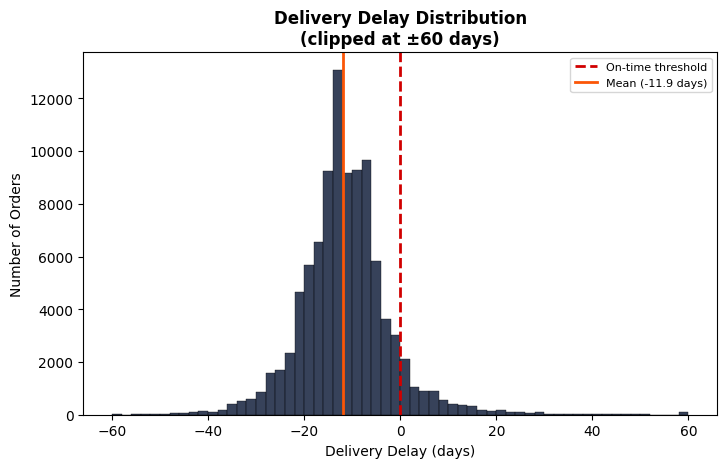

In [26]:
fig = plt.figure(figsize=(18,16))

ax1 = fig.add_subplot(3,2,1)

delay_clipped = delivered_orders['delivery_delay_days'].clip(-60,60)

ax1.hist(
    delay_clipped,
    bins=60,
    color=COLOUR_PRIMARY,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.85
)

ax1.axvline(
    x=0,
    color=COLOUR_EMPHASIS,
    linewidth=2,
    linestyle='--',
    label='On-time threshold'
)
ax1.axvline(
    x=delay_clipped.mean(),
    color=COLOUR_HIGHLIGHT,
    linewidth=2,
    linestyle='-',
    label=f'Mean ({delay_clipped.mean():.1f} days)'
)
ax1.set_xlabel('Delivery Delay (days)')
ax1.set_ylabel('Number of Orders')
ax1.set_title('Delivery Delay Distribution\n(clipped at ±60 days)', fontweight='bold')
ax1.legend(fontsize=8)

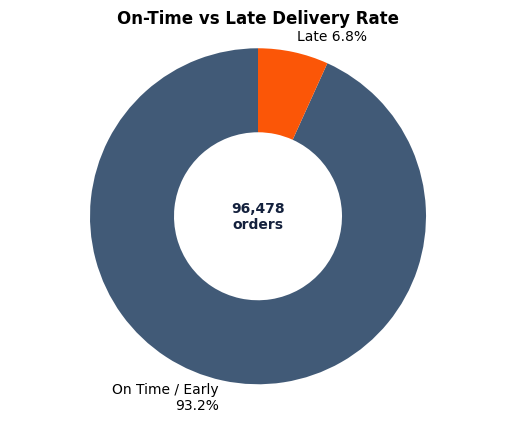

In [27]:
fig, ax2 = plt.subplots()
sizes  = [on_time_rate, late_rate]
labels = [f'On Time / Early\n{on_time_rate:.1f}%',
          f'Late {late_rate:.1f}%']
colours = [COLOUR_ACCENT, COLOUR_HIGHLIGHT]

ax2.set_title('On-Time vs Late Delivery Rate', fontweight='bold')

wedges, texts, *rest = ax2.pie(
    sizes,
    labels=labels,
    colors=colours,
    startangle=90,
     wedgeprops=dict(width=0.5),   # Width < 1 makes it a donut, so we can see the total.
    textprops=dict(fontsize=10)
)
ax2.text(
    0, 0,
    f'{len(delivered_orders):,}\norders',
    ha='center', va='center',
    fontsize=10, fontweight='bold',
    color=COLOUR_PRIMARY
)

ax2.axis('equal')

plt.show()

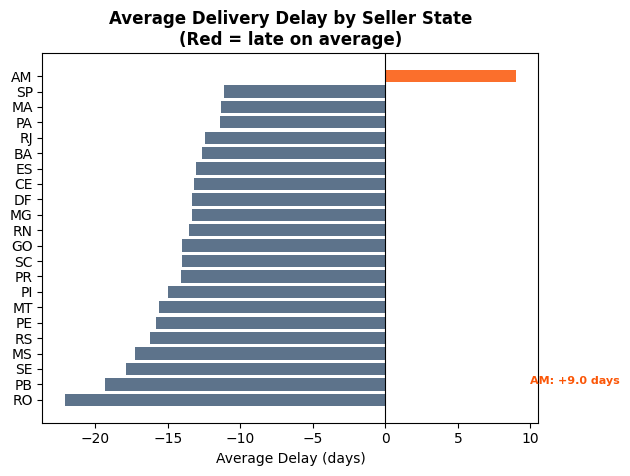

In [28]:

fig, ax3 = plt.subplots()
# Colour each bar based on whether state is late or early
state_colours = [
    COLOUR_HIGHLIGHT if x > 0 else COLOUR_ACCENT
    for x in delay_by_state['delivery_delay_days']
]
 
bars = ax3.barh(
    delay_by_state['seller_state'][::-1],
    delay_by_state['delivery_delay_days'][::-1],
    color=state_colours[::-1],
    alpha=0.85
)
ax3.axvline(x=0, color='black', linewidth=0.8)
ax3.set_xlabel('Average Delay (days)')
ax3.set_title('Average Delivery Delay by Seller State\n(Red = late on average)', fontweight='bold')
 
# Annotate the AM bar specifically
am_val = delay_by_state[delay_by_state['seller_state'] == 'AM']['delivery_delay_days']
if len(am_val) > 0:
    ax3.annotate(
        f'AM: +{am_val.values[0]:.1f} days',
        xy=(am_val.values[0], 0),
        xytext=(am_val.values[0] + 1, 1),
        fontsize=8, color=COLOUR_HIGHLIGHT, fontweight='bold'
    )

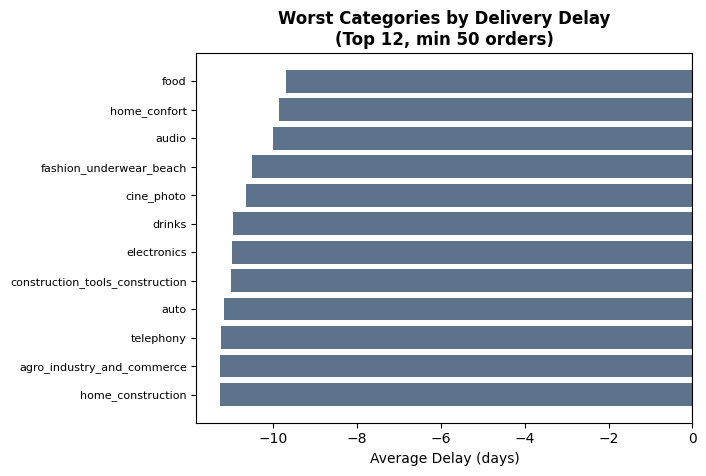

In [29]:

fig, ax4 = plt.subplots()
# Show top 12 worst categories
worst_cats = delay_by_category.head(12)
 
cat_colours = [
    COLOUR_HIGHLIGHT if x > 0 else COLOUR_ACCENT
    for x in worst_cats['delivery_delay_days']
]
 
ax4.barh(
    worst_cats['product_category_name_english'][::-1],
    worst_cats['delivery_delay_days'][::-1],
    color=cat_colours[::-1],
    alpha=0.85
)
ax4.axvline(x=0, color='black', linewidth=0.8)
ax4.set_xlabel('Average Delay (days)')
ax4.set_title('Worst Categories by Delivery Delay\n(Top 12, min 50 orders)', fontweight='bold')
ax4.tick_params(axis='y', labelsize=8)

Text(2, 2.4208039492242595, 'μ=2.27')

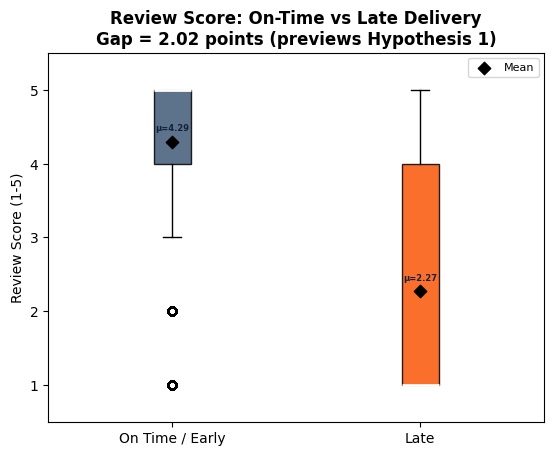

In [30]:
fig, ax5 = plt.subplots()
 

late_reviews    = delivered_orders[delivered_orders['was_late'] == True]['review_score'].dropna()
on_time_reviews = delivered_orders[delivered_orders['was_late'] == False]['review_score'].dropna()
 
bp = ax5.boxplot(
    [on_time_reviews, late_reviews],
    tick_labels=['On Time / Early', 'Late'],
    patch_artist=True,   
    medianprops=dict(color='white', linewidth=2)
)
 
# Colour the two boxes differently
bp['boxes'][0].set_facecolor(COLOUR_ACCENT)
bp['boxes'][1].set_facecolor(COLOUR_HIGHLIGHT)
for patch in bp['boxes']:
    patch.set_alpha(0.85)
 
# Add mean markers
ax5.scatter(
    [1, 2],
    [on_time_reviews.mean(), late_reviews.mean()],
    marker='D',
    color='black',
    s=40,
    zorder=3,
    label='Mean'
)
 
ax5.set_ylabel('Review Score (1-5)')
ax5.set_title(
    f'Review Score: On-Time vs Late Delivery\n'
    f'Gap = {review_gap:.2f} points (previews Hypothesis 1)',
    fontweight='bold'
)
ax5.set_ylim(0.5, 5.5)
ax5.legend(fontsize=8)
 
# Add mean value labels
ax5.text(1, on_time_reviews.mean() + 0.15,
         f'μ={on_time_reviews.mean():.2f}',
         ha='center', fontsize=6, color=COLOUR_PRIMARY, fontweight='semibold')
ax5.text(2, late_reviews.mean() + 0.15,
         f'μ={late_reviews.mean():.2f}',
         ha='center', fontsize=6, color=COLOUR_PRIMARY, fontweight='semibold')
 

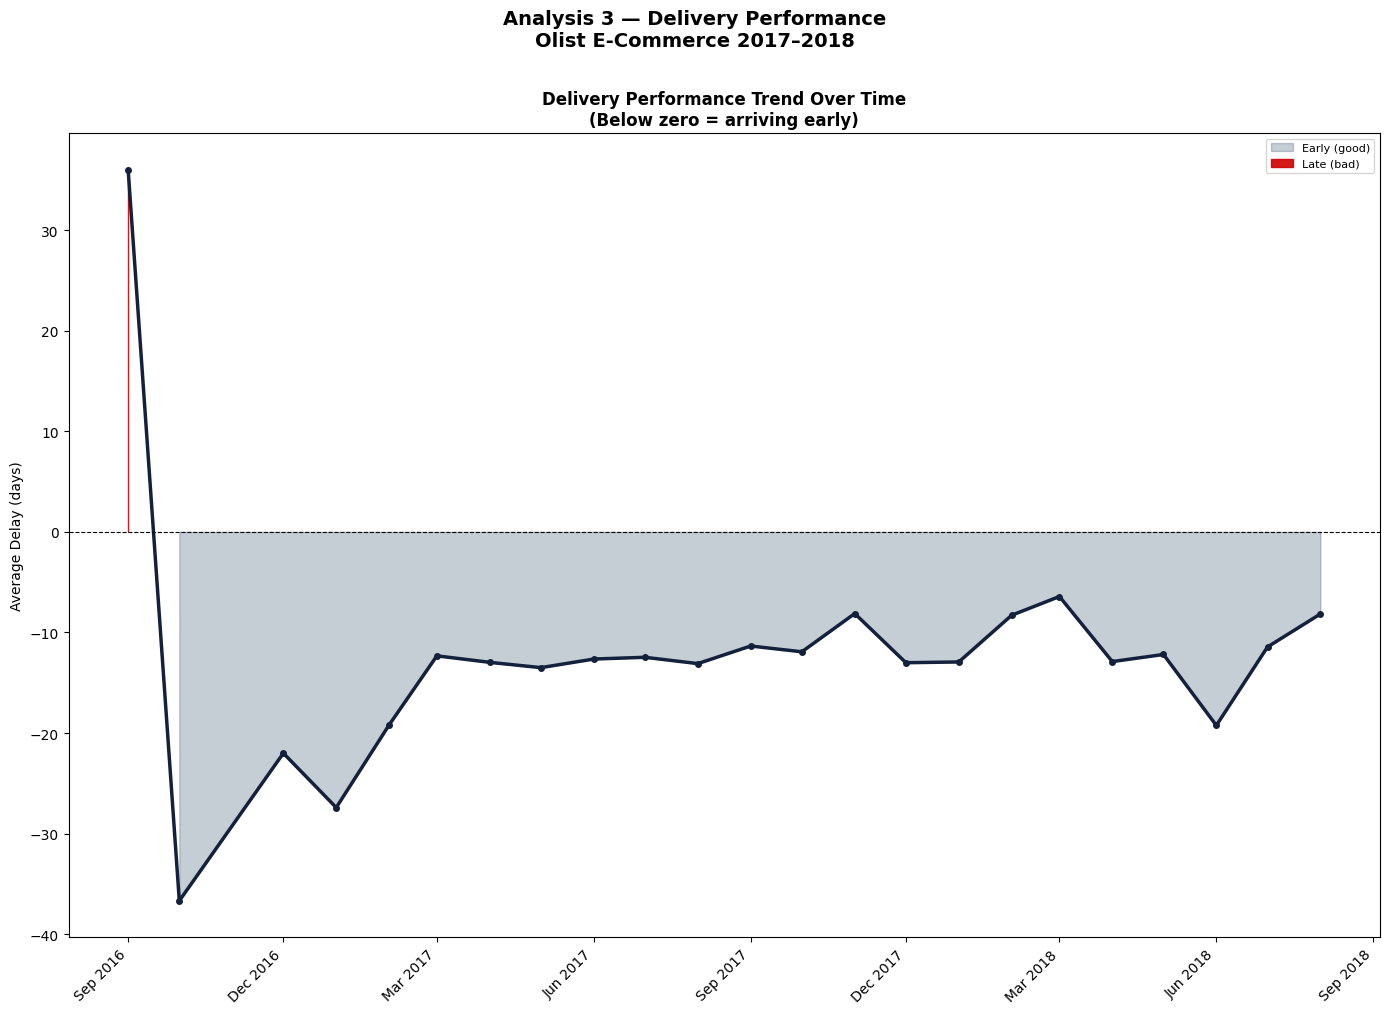

Saved to outputs/figures/03_delivery_performance.png


In [31]:
fig, ax6 = plt.subplots(figsize=(14,10))
 
delivered_orders['order_month'] = (
    delivered_orders['order_purchase_timestamp'].dt.to_period('M')
)
 
monthly_delay = (
    delivered_orders
    .groupby('order_month')['delivery_delay_days']
    .mean()
    .reset_index()
)
monthly_delay['month_dt'] = monthly_delay['order_month'].dt.to_timestamp()
 

 
ax6.plot(
    monthly_delay['month_dt'],
    monthly_delay['delivery_delay_days'],
    color=COLOUR_PRIMARY,
    linewidth=2.5,
    marker='o',
    markersize=4
)
ax6.fill_between(
    monthly_delay['month_dt'],
    monthly_delay['delivery_delay_days'],
    0,
    where=(monthly_delay['delivery_delay_days'] < 0).to_numpy(), #PYLANCE 
    alpha=0.3,
    color=COLOUR_ACCENT,
    label='Early (good)'
)
ax6.fill_between(
    monthly_delay['month_dt'],
    monthly_delay['delivery_delay_days'],
    0,
    where=monthly_delay['delivery_delay_days'] > 0,
    alpha=0.9,
    color=COLOUR_EMPHASIS,
    label='Late (bad)'
)
ax6.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
 

ax6.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax6.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')
 
ax6.set_ylabel('Average Delay (days)')
ax6.set_title('Delivery Performance Trend Over Time\n(Below zero = arriving early)', fontweight='bold')
ax6.legend(fontsize=8)
plt.suptitle(
    'Analysis 3 — Delivery Performance\nOlist E-Commerce 2017–2018',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

plt.show()
print("Saved to outputs/figures/03_delivery_performance.png")

/tmp/ipykernel_8485/1681038268.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(


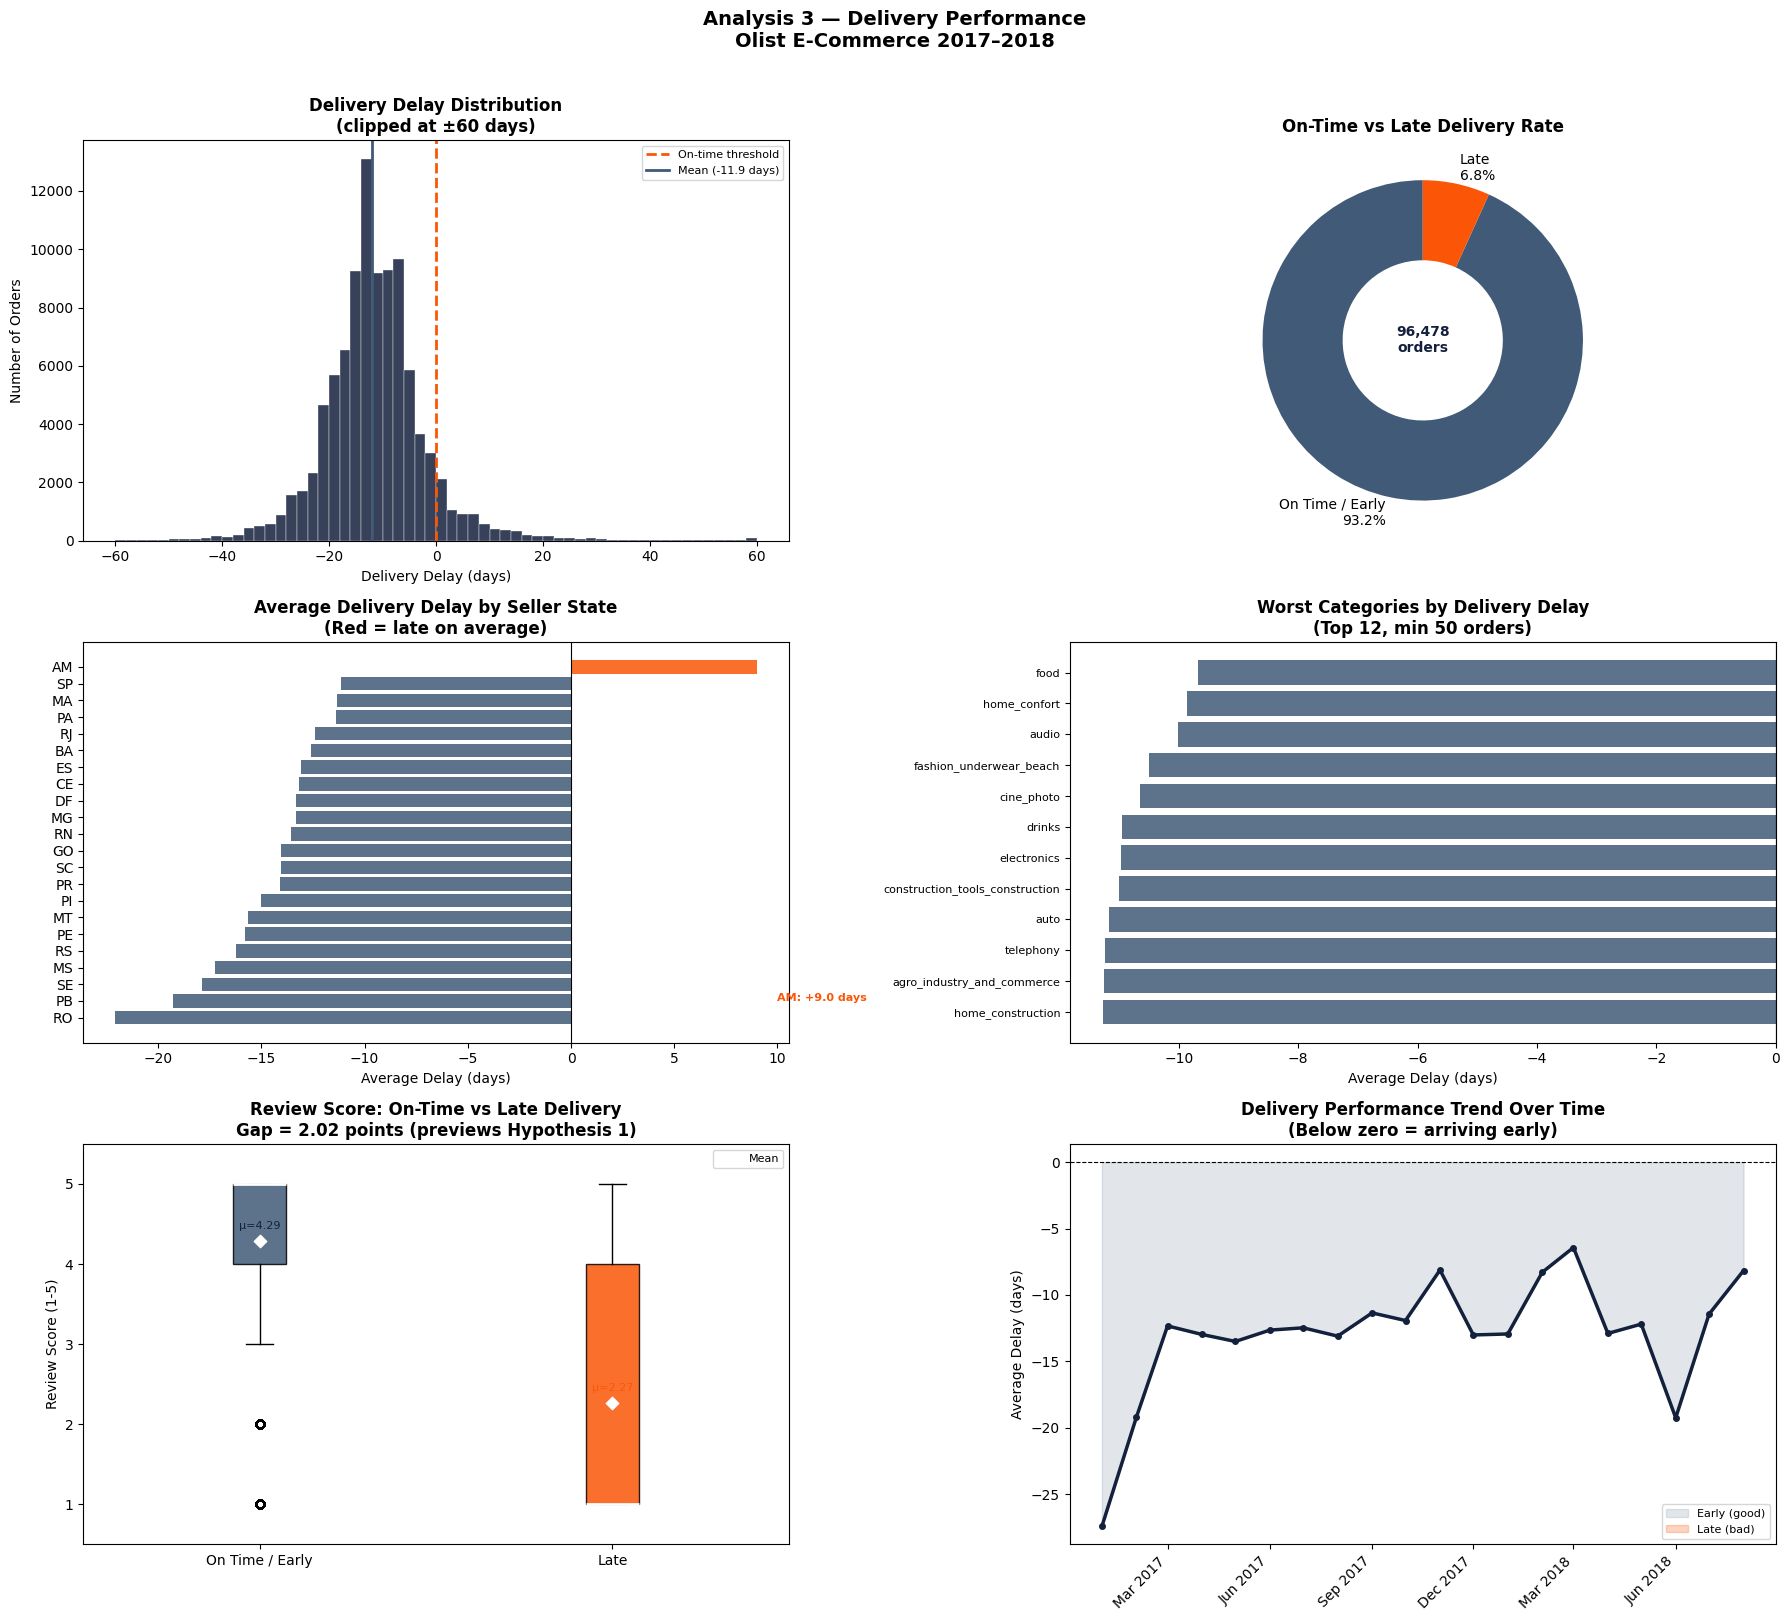

Saved to outputs/figures/03_delivery_performance.png


In [32]:
fig = plt.figure(figsize=(18, 16))
 
# ── Chart 1: Delay distribution histogram ─────────────────
ax1 = fig.add_subplot(3, 2, 1)
 
delay_clipped = delivered_orders['delivery_delay_days'].clip(-60, 60)
 
ax1.hist(
    delay_clipped,
    bins=60,
    color=COLOUR_PRIMARY,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.85
)
ax1.axvline(
    x=0,
    color=COLOUR_HIGHLIGHT,
    linewidth=2,
    linestyle='--',
    label='On-time threshold'
)
ax1.axvline(
    x=delay_clipped.mean(),
    color=COLOUR_ACCENT,
    linewidth=2,
    linestyle='-',
    label=f'Mean ({delay_clipped.mean():.1f} days)'
)
ax1.set_xlabel('Delivery Delay (days)')
ax1.set_ylabel('Number of Orders')
ax1.set_title('Delivery Delay Distribution\n(clipped at ±60 days)', fontweight='bold')
ax1.legend(fontsize=8)
 
# ── Chart 2: On-time vs late donut ────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
 
sizes  = [on_time_rate, late_rate]
labels = [f'On Time / Early\n{on_time_rate:.1f}%',
          f'Late\n{late_rate:.1f}%']
colours = [COLOUR_ACCENT, COLOUR_HIGHLIGHT]
 
wedges, texts = ax2.pie(
    sizes,
    labels=labels,
    colors=colours,
    startangle=90,
    wedgeprops=dict(width=0.5),   # Width < 1 makes it a donut
    textprops=dict(fontsize=10)
)
ax2.set_title('On-Time vs Late Delivery Rate', fontweight='bold')
 
# Add total in the centre of the donut
ax2.text(
    0, 0,
    f'{len(delivered_orders):,}\norders',
    ha='center', va='center',
    fontsize=10, fontweight='bold',
    color=COLOUR_PRIMARY
)
 
# ── Chart 3: Average delay by seller state ────────────────
ax3 = fig.add_subplot(3, 2, 3)
 
# Colour each bar based on whether state is late or early
state_colours = [
    COLOUR_HIGHLIGHT if x > 0 else COLOUR_ACCENT
    for x in delay_by_state['delivery_delay_days']
]
 
bars = ax3.barh(
    delay_by_state['seller_state'][::-1],
    delay_by_state['delivery_delay_days'][::-1],
    color=state_colours[::-1],
    alpha=0.85
)
ax3.axvline(x=0, color='black', linewidth=0.8)
ax3.set_xlabel('Average Delay (days)')
ax3.set_title('Average Delivery Delay by Seller State\n(Red = late on average)', fontweight='bold')
 
# Annotate the AM bar specifically
am_val = delay_by_state[delay_by_state['seller_state'] == 'AM']['delivery_delay_days']
if len(am_val) > 0:
    ax3.annotate(
        f'AM: +{am_val.values[0]:.1f} days',
        xy=(am_val.values[0], 0),
        xytext=(am_val.values[0] + 1, 1),
        fontsize=8, color=COLOUR_HIGHLIGHT, fontweight='bold'
    )
 
# ── Chart 4: Worst categories by delay ────────────────────
ax4 = fig.add_subplot(3, 2, 4)
 
# Show top 12 worst categories
worst_cats = delay_by_category.head(12)
 
cat_colours = [
    COLOUR_HIGHLIGHT if x > 0 else COLOUR_ACCENT
    for x in worst_cats['delivery_delay_days']
]
 
ax4.barh(
    worst_cats['product_category_name_english'][::-1],
    worst_cats['delivery_delay_days'][::-1],
    color=cat_colours[::-1],
    alpha=0.85
)
ax4.axvline(x=0, color='black', linewidth=0.8)
ax4.set_xlabel('Average Delay (days)')
ax4.set_title('Worst Categories by Delivery Delay\n(Top 12, min 50 orders)', fontweight='bold')
ax4.tick_params(axis='y', labelsize=8)
 
# ── Chart 5: Review score — late vs on-time ───────────────
ax5 = fig.add_subplot(3, 2, 5)
 
# Box plot shows the full distribution — not just the mean
# This is more informative than a simple bar chart of averages
late_reviews    = delivered_orders[delivered_orders['was_late'] == True]['review_score'].dropna()
on_time_reviews = delivered_orders[delivered_orders['was_late'] == False]['review_score'].dropna()
 
bp = ax5.boxplot(
    [on_time_reviews, late_reviews],
    labels=['On Time / Early', 'Late'],
    patch_artist=True,      # Fills the boxes with colour
    medianprops=dict(color='white', linewidth=2)
)
 
# Colour the two boxes differently
bp['boxes'][0].set_facecolor(COLOUR_ACCENT)
bp['boxes'][1].set_facecolor(COLOUR_HIGHLIGHT)
for patch in bp['boxes']:
    patch.set_alpha(0.85)
 
# Add mean markers
ax5.scatter(
    [1, 2],
    [on_time_reviews.mean(), late_reviews.mean()],
    marker='D',
    color='white',
    s=40,
    zorder=3,
    label='Mean'
)
 
ax5.set_ylabel('Review Score (1-5)')
ax5.set_title(
    f'Review Score: On-Time vs Late Delivery\n'
    f'Gap = {review_gap:.2f} points (previews Hypothesis 1)',
    fontweight='bold'
)
ax5.set_ylim(0.5, 5.5)
ax5.legend(fontsize=8)
 
# Add mean value labels
ax5.text(1, on_time_reviews.mean() + 0.15,
         f'μ={on_time_reviews.mean():.2f}',
         ha='center', fontsize=8, color=COLOUR_PRIMARY)
ax5.text(2, late_reviews.mean() + 0.15,
         f'μ={late_reviews.mean():.2f}',
         ha='center', fontsize=8, color=COLOUR_HIGHLIGHT)
 
# ── Chart 6: Delay over time ──────────────────────────────
# Does delivery performance improve or worsen over time?
# This is an extra chart that adds a time dimension
ax6 = fig.add_subplot(3, 2, 6)
 
delivered_orders['order_month'] = (
    delivered_orders['order_purchase_timestamp'].dt.to_period('M')
)
 
monthly_delay = (
    delivered_orders
    .groupby('order_month')['delivery_delay_days']
    .mean()
    .reset_index()
)
monthly_delay['month_dt'] = monthly_delay['order_month'].dt.to_timestamp()
 
# Filter to complete months only (same logic as Analysis 1)
monthly_delay = monthly_delay[
    (monthly_delay['order_month'] >= pd.Period('2017-01', 'M')) &
    (monthly_delay['order_month'] <= pd.Period('2018-08', 'M'))
].copy()
 
ax6.plot(
    monthly_delay['month_dt'],
    monthly_delay['delivery_delay_days'],
    color=COLOUR_PRIMARY,
    linewidth=2.5,
    marker='o',
    markersize=4
)
ax6.fill_between(
    monthly_delay['month_dt'],
    monthly_delay['delivery_delay_days'],
    0,
    where=monthly_delay['delivery_delay_days'] < 0,
    alpha=0.15,
    color=COLOUR_ACCENT,
    label='Early (good)'
)
ax6.fill_between(
    monthly_delay['month_dt'],
    monthly_delay['delivery_delay_days'],
    0,
    where=monthly_delay['delivery_delay_days'] > 0,
    alpha=0.25,
    color=COLOUR_HIGHLIGHT,
    label='Late (bad)'
)
ax6.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
 
import matplotlib.dates as mdates
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax6.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')
 
ax6.set_ylabel('Average Delay (days)')
ax6.set_title('Delivery Performance Trend Over Time\n(Below zero = arriving early)', fontweight='bold')
ax6.legend(fontsize=8)
 
# ── Final formatting ───────────────────────────────────────
plt.suptitle(
    'Analysis 3 — Delivery Performance\nOlist E-Commerce 2017–2018',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

plt.show()
print("Saved to outputs/figures/03_delivery_performance.png")

## Analysis 3 — Delivery Performance: Observations & Findings
 
---
 
### Finding 1 — Olist Over-Delivers On Its Promises
 
The platform-wide mean delivery delay is **-11.9 days**,meaning the average order arrives nearly 12 days before the estimated date shown to the customer.
 
**93.2% of orders arrive on time or early.** Only **6.8% of orders are genuinely late.**
 
This is a deliberate under-promise / over-deliver strategy.Customers are pleasantly surprised by early arrival rather than frustrated by late delivery. The strategy appears to be working ,but it carries a risk: if actual delivery slows down without adjusting estimates, the experience degrades sharply.
 
---
 
### Finding 2 — Amazonas (AM) Is The Only Problem State
 
Of 22 states with delivered orders, **21 average early delivery** and only **1 averages late: Amazonas (AM) at +9.0 days late on average.**
 
AM is geographically isolated in the Amazon basin. Logistics infrastructure to reach customers there is significantly more challenging than coastal states. This is a known logistics challenge in Brazil rather than a seller performance issue.
 
*Implication: Sellers shipping to AM customers should be given adjusted delivery estimates that account for the logistical reality of the region.*
 
---
 
### Finding 3 — Late Delivery Review Score Points
 
Orders that arrived late received an average review score of **2.27** compared to **4.29** for on-time orders a gap of **2.02 points** on a 5-point scale.
 
This relationship will be formally tested in Notebook 02 (Hypothesis 1 — Mann-Whitney U test) to confirm it is statistically significant and not a sampling artefact.
 
*Implication: Every percentage point reduction in the late delivery rate has a measurable, quantifiable impact on
customer satisfaction scores.*
 
---
 
### Finding 4 — Delivery Performance Stable Over Time
 
The time trend chart shows delivery performance is stable  across the analysis
period. The lie trend is below the mean line.
 
---
 
### Methodological Notes
 
- Analysis filtered to delivered orders only
  (order_status == 'delivered': 96,478 orders)
- Deduplicated to order level before all calculations
- Category analysis limited to categories with ≥50 orders
  to avoid unreliable averages from small samples
- Delay distribution chart clipped at ±60 days for visual
  clarity  true range is -147 to +188 days
 
---
*Connects to: Analysis 4 (Satisfaction) : delivery delay
is one of the primary drivers of review score variation.
Formally tested in: Notebook 02, Hypothesis 1.*
"""
 

---
# Analysis 4 Satisfactory Analysis 

### Business Questions :
1. What does overall satisfaction look like across the platform?
2. Which product categories have the best and worst satisfaction?
3. Does delivery delay drive low satisfaction scores?
4. Does satisfaction vary by customer geography?

 
**Why this matters:**
Review score is the primary public signal of customer experience. Low scores damage seller reputation, reduce repeat purchase probability, and in a marketplace model
like Olist, can lead to seller removal. Understanding where satisfaction breaks down and why is foundational to any
retention strategy.

---

In [33]:
master['review_score'].isna().sum()

np.int64(961)

In [34]:
master['review_score'].value_counts()

review_score
5.0    63208
4.0    21237
1.0    14683
3.0     9429
2.0     3907
Name: count, dtype: int64

In [35]:
reviewed = master[master['review_score'].notna()].copy()

In [36]:
reviewed_orders = reviewed.drop_duplicates(subset='order_id').copy()

In [37]:
print('='* 50)
print('Summary')
print('='*50)
print(f"master rows (item level):           {len(master):,}")
print(f"Rows with review scores:            {len(reviewed):,}")
print(f"Orders with review scores (deduped):{len(reviewed_orders):,}")
print(f"Orders without review score:        {master['order_id'].nunique() - len(reviewed_orders):,}")
print(f"Review coverage:                    "
      f"{len(reviewed_orders)/master['order_id'].nunique()*100:.1f}%")
 

Summary
master rows (item level):           113,425
Rows with review scores:            112,464
Orders with review scores (deduped):98,673
Orders without review score:        768
Review coverage:                    99.2%


In [38]:
score_counts = reviewed_orders['review_score'].value_counts().sort_index()
score_pcts   = score_counts / len(reviewed_orders) * 100

dissatisfied = reviewed_orders['review_score'].isin([1, 2]).mean() * 100
neutral      = reviewed_orders['review_score'].isin([3]).mean() * 100
satisfied    = reviewed_orders['review_score'].isin([4, 5]).mean() * 100
mean_score   = reviewed_orders['review_score'].mean()

print("=" * 50)
print("  OVERALL SATISFACTION SUMMARY")
print("=" * 50)
print(f"  Mean review score:  {mean_score:.2f} / 5.00")
print(f"  Dissatisfied (1-2): {dissatisfied:.1f}%")
print(f"  Neutral (3):        {neutral:.1f}%")
print(f"  Satisfied (4-5):    {satisfied:.1f}%")
print()
print("  Score breakdown:")
for score, count in score_counts.items():
    bar = '█' * int(score_pcts[score] / 2)
    print(f"  {score} stars: {bar:<30} {count:>6,} ({score_pcts[score]:4.1f}%)")
 

  OVERALL SATISFACTION SUMMARY
  Mean review score:  4.09 / 5.00
  Dissatisfied (1-2): 14.7%
  Neutral (3):        8.2%
  Satisfied (4-5):    77.1%

  Score breakdown:
  1.0 stars: █████                          11,365 (11.5%)
  2.0 stars: █                               3,130 ( 3.2%)
  3.0 stars: ████                            8,134 ( 8.2%)
  4.0 stars: █████████                      19,043 (19.3%)
  5.0 stars: ████████████████████████████   57,001 (57.8%)


In [39]:
reviewed_full = master[master['review_score'].notna()].copy()
 
category_stats = (
    reviewed_full
    .groupby('product_category_name_english')
    .agg(
        avg_score   = ('review_score', 'mean'),
        order_count = ('order_id', 'nunique'),
        score_std   = ('review_score', 'std'),
    )
    .reset_index()
)

category_stats.head()

,product_category_name_english,avg_score,order_count,score_std
0,agro_industry_and_commerce,4.000000,182,1.363019
1,air_conditioning,3.969178,249,1.453427
2,art,3.937198,200,1.455127
3,arts_and_craftmanship,4.125000,23,1.392917
4,audio,3.833333,347,1.513173


In [40]:
category_stats = category_stats[category_stats['order_count'] >= 50].copy()
category_stats = category_stats.sort_values('avg_score', ascending=False).reset_index(drop=True)

In [41]:
print(f"Categories with 50+ orders: {len(category_stats)}")
print(f"\nTop 10 highest satisfaction categories:")
print(category_stats.head(10)[
    ['product_category_name_english', 'avg_score', 'order_count']
].to_string(index=False))
 
print(f"\nBottom 10 lowest satisfaction categories:")
print(category_stats.tail(10)[
    ['product_category_name_english', 'avg_score', 'order_count']
].to_string(index=False))

Categories with 50+ orders: 59

Top 10 highest satisfaction categories:
        product_category_name_english  avg_score  order_count
               books_general_interest   4.446266          508
              costruction_tools_tools   4.444444           94
                       books_imported   4.400000           53
                      books_technical   4.363636          257
                  luggage_accessories   4.315257         1030
                           food_drink   4.310469          226
small_appliances_home_oven_and_coffee   4.302632           75
                        fashion_shoes   4.228682          236
                                 food   4.218182          445
                           stationery   4.196078         2295

Bottom 10 lowest satisfaction categories:
product_category_name_english  avg_score  order_count
              furniture_decor   3.904848         6398
        furniture_living_room   3.901606          417
               bed_bath_table   3.897469 

In [42]:
reviewed_orders['delay_bin'] = pd.cut(
    reviewed_orders['delivery_delay_days'],
    bins=[-float('inf'), -14, -1, 0, 7, float('inf')],
    labels=[
        'Very Early\n(<-14 days)',
        'Early\n(-1 to -14)',
        'On Time\n(0 days)',
        'Slightly Late\n(1-7 days)',
        'Very Late\n(>7 days)'
    ]
)

In [43]:
delay_bin_stats = (
    reviewed_orders
    .groupby('delay_bin', observed=True)
    .agg(
        avg_score   = ('review_score', 'mean'),
        order_count = ('order_id', 'count'),
    )
    .reset_index()
)
 

corr_data = reviewed_orders[
    ['delivery_delay_days', 'review_score']
].dropna()
correlation = corr_data['delivery_delay_days'].corr(corr_data['review_score'])
 
print("Mean review score by delivery delay bin:")
print(delay_bin_stats.to_string(index=False))
print(f"\nCorrelation (delay vs review score): {correlation:.4f}")
print(f"Interpretation: {'Negative' if correlation < 0 else 'Positive'} correlation :")
print(f"  longer delays are {'associated with lower' if correlation < 0 else 'associated with higher'} scores")
 
 

Mean review score by delivery delay bin:
                delay_bin  avg_score  order_count
  Very Early\n(<-14 days)   4.323580        41866
       Early\n(-1 to -14)   4.266986        46302
        On Time\n(0 days)   4.033594         1280
Slightly Late\n(1-7 days)   2.715000         3600
     Very Late\n(>7 days)   1.696262         2782

Correlation (delay vs review score): -0.2669
Interpretation: Negative correlation :
  longer delays are associated with lower scores


In [44]:
state_satisfaction = (
    reviewed_orders
    .groupby('customer_state')
    .agg(
        avg_score   = ('review_score', 'mean'),
        order_count = ('order_id', 'count'),
    )
    .reset_index()
)
 
state_satisfaction = (
    state_satisfaction[state_satisfaction['order_count'] >= 100]
    .sort_values('avg_score', ascending=False)
    .reset_index(drop=True)
)
 
overall_mean = reviewed_orders['review_score'].mean()
 
print(f"States with 100+ reviewed orders: {len(state_satisfaction)}")
print(f"Overall platform mean:            {overall_mean:.2f}")
print()
print("Satisfaction by state:")
print(state_satisfaction[
    ['customer_state', 'avg_score', 'order_count']
].to_string(index=False))

States with 100+ reviewed orders: 24
Overall platform mean:            4.09

Satisfaction by state:
customer_state  avg_score  order_count
            AM   4.205479          146
            PR   4.181311         5019
            SP   4.173201        41472
            MG   4.135191        11554
            RS   4.132280         5443
            MS   4.110799          713
            RN   4.104167          480
            MT   4.101111          900
            TO   4.096774          279
            SC   4.073982         3609
            DF   4.063910         2128
            RO   4.051587          252
            GO   4.042850         2007
            ES   4.037388         2006
            PB   4.016981          530
            PE   4.009174         1635
            PI   3.918367          490
            RJ   3.877512        12687
            BA   3.860778         3340
            CE   3.856712         1326
            PA   3.850312          962
            SE   3.808023          349
   

[Text(1, 0, '1\nVery Bad'),
 Text(2, 0, '2\nBad'),
 Text(3, 0, '3\nNeutral'),
 Text(4, 0, '4\nGood'),
 Text(5, 0, '5\nExcellent')]

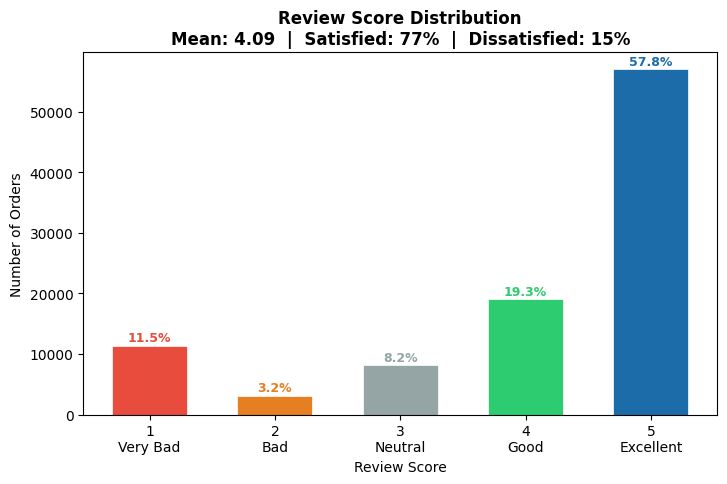

In [45]:
# ── Chart 1: Review score distribution ────────────────────
fig = plt.figure(figsize=(18, 16))
ax1 = fig.add_subplot(3, 2, 1)
 
bar_colours = {
    1: '#E74C3C',   # Red — very dissatisfied
    2: '#E67E22',   # Orange — dissatisfied
    3: '#95A5A6',   # Grey — neutral
    4: '#2ECC71',   # Light green — satisfied
    5: '#1B6CA8',   # Blue — very satisfied
}
 
bars = ax1.bar(
    score_counts.index,
    score_counts.values,
    color=[bar_colours[s] for s in score_counts.index],
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)

for bar, (score, pct) in zip(bars, score_pcts.items()):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
        color=bar_colours[score]
    )
 
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Number of Orders')
ax1.set_title(
    f'Review Score Distribution\n'
    f'Mean: {mean_score:.2f}  |  '
    f'Satisfied: {satisfied:.0f}%  |  '
    f'Dissatisfied: {dissatisfied:.0f}%',
    fontweight='bold'
)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['1\nVery Bad', '2\nBad', '3\nNeutral', '4\nGood', '5\nExcellent'])

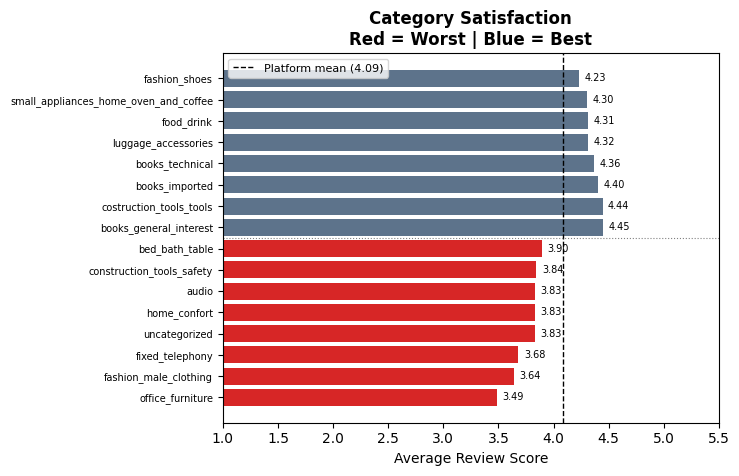

In [46]:
fig, ax2 = plt.subplots()
 
n_show = 8
best  = category_stats.head(n_show)
worst = category_stats.tail(n_show).sort_values('avg_score')
 
# Combine into one chart with a visual gap
all_cats   = pd.concat([worst, best])
all_scores = all_cats['avg_score'].values
all_names  = all_cats['product_category_name_english'].values
colours    = (
    [COLOUR_EMPHASIS] * n_show +
    [COLOUR_ACCENT] * n_show
)
 
bars2 = ax2.barh(range(len(all_cats)), all_scores, color=colours, alpha=0.85)
 
ax2.set_yticks(range(len(all_cats)))
ax2.set_yticklabels(all_names, fontsize=7)
ax2.axvline(x=mean_score, color='black', linewidth=1,
            linestyle='--', label=f'Platform mean ({mean_score:.2f})')
ax2.axhline(y=n_show - 0.5, color='grey', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Average Review Score')
ax2.set_title('Category Satisfaction\nRed = Worst | Blue = Best', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim(1, 5.5)
 
# Score labels
for i, (bar, score) in enumerate(zip(bars2, all_scores)):
    ax2.text(
        score + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{score:.2f}',
        va='center', fontsize=7
    )



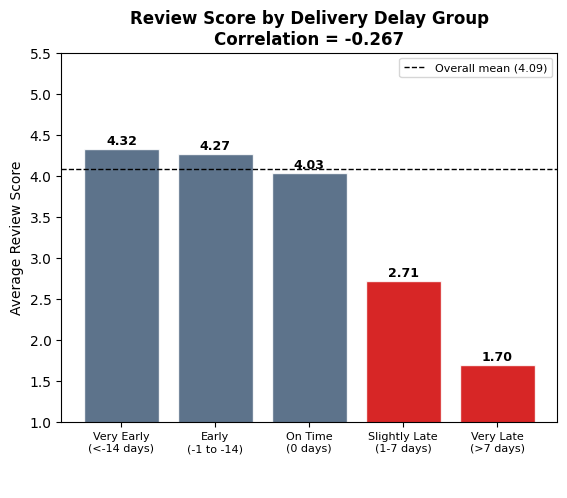

In [47]:
fig , ax3 = plt.subplots()
 
bin_colours = [COLOUR_ACCENT] * len(delay_bin_stats)
 
# Colour late bins red
for i, label in enumerate(delay_bin_stats['delay_bin'].astype(str)):
    if 'Late' in label:
        bin_colours[i] = COLOUR_EMPHASIS
 
bars3 = ax3.bar(
    range(len(delay_bin_stats)),
    delay_bin_stats['avg_score'],
    color=bin_colours,
    alpha=0.85,
    edgecolor='white'
)

for i, (bar, row) in enumerate(zip(bars3, delay_bin_stats.itertuples())):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{row.avg_score:.2f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        0.2,
        f'n={row.order_count:,}',
        ha='center', va='bottom',
        fontsize=7, color='white'
    )
 
ax3.axhline(y=mean_score, color='black', linewidth=1,
            linestyle='--', label=f'Overall mean ({mean_score:.2f})')
ax3.set_xticks(range(len(delay_bin_stats)))
ax3.set_xticklabels(
    delay_bin_stats['delay_bin'].astype(str),
    fontsize=8
)
ax3.set_ylabel('Average Review Score')
ax3.set_ylim(1, 5.5)
ax3.set_title(
    f'Review Score by Delivery Delay Group\n'
    f'Correlation = {correlation:.3f}',
    fontweight='bold'
)
ax3.legend(fontsize=8)

(1.0, 5.5)

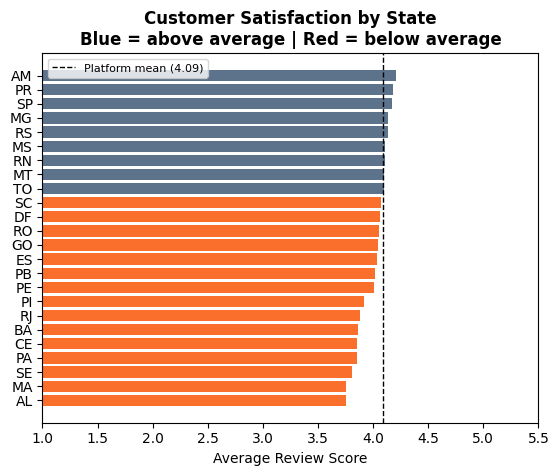

In [48]:
# ── Chart 4: Satisfaction by state ────────────────────────
fig , ax4 = plt.subplots()
 
state_colours = [
    COLOUR_ACCENT if s >= mean_score else COLOUR_HIGHLIGHT
    for s in state_satisfaction['avg_score']
]
 
ax4.barh(
    state_satisfaction['customer_state'][::-1],
    state_satisfaction['avg_score'][::-1],
    color=state_colours[::-1],
    alpha=0.85
)
ax4.axvline(
    x=mean_score,
    color='black', linewidth=1,
    linestyle='--',
    label=f'Platform mean ({mean_score:.2f})'
)
ax4.set_xlabel('Average Review Score')
ax4.set_title(
    'Customer Satisfaction by State\n'
    'Blue = above average | Red = below average',
    fontweight='bold'
)
ax4.legend(fontsize=8)
ax4.set_xlim(1, 5.5)
 


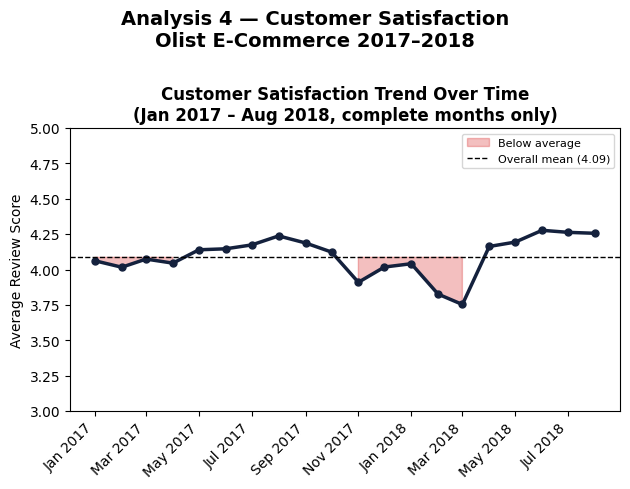

In [49]:
# ── Chart 5: Score distribution by segment ────────────────
 
fig, ax5 = plt.subplots()
reviewed_orders['order_month'] = (
    reviewed_orders['order_purchase_timestamp'].dt.to_period('M')
)
reviewed_orders = reviewed_orders[
    (reviewed_orders['order_month'] >= pd.Period('2017-01', 'M')) &
    (reviewed_orders['order_month'] <= pd.Period('2018-08', 'M'))
].copy()

monthly_satisfaction = (
   reviewed_orders
    .groupby('order_month')['review_score']
    .mean()
    .reset_index()
)


monthly_satisfaction['month_dt'] = (
    monthly_satisfaction['order_month'].dt.to_timestamp()
)
 
ax5.plot(
    monthly_satisfaction['month_dt'],
    monthly_satisfaction['review_score'],
    color=COLOUR_PRIMARY,
    linewidth=2.5,
    marker='o',
    markersize=5
)
ax5.fill_between(
    monthly_satisfaction['month_dt'],
    monthly_satisfaction['review_score'],
    mean_score,
    where=monthly_satisfaction['review_score'] < mean_score,
    alpha=0.25,
    color=COLOUR_EMPHASIS,
    label='Below average'
)
ax5.axhline(
    y=mean_score,
    color='black',
    linewidth=1,
    linestyle='--',
    label=f'Overall mean ({mean_score:.2f})'
)
import matplotlib.dates as mdates
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
 
ax5.set_ylabel('Average Review Score')
ax5.set_ylim(3, 5)
ax5.set_title(
    'Customer Satisfaction Trend Over Time\n'
    '(Jan 2017 – Aug 2018, complete months only)',
    fontweight='bold'
)
ax5.legend(fontsize=8)
 
plt.suptitle(
    'Analysis 4 — Customer Satisfaction\nOlist E-Commerce 2017–2018',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

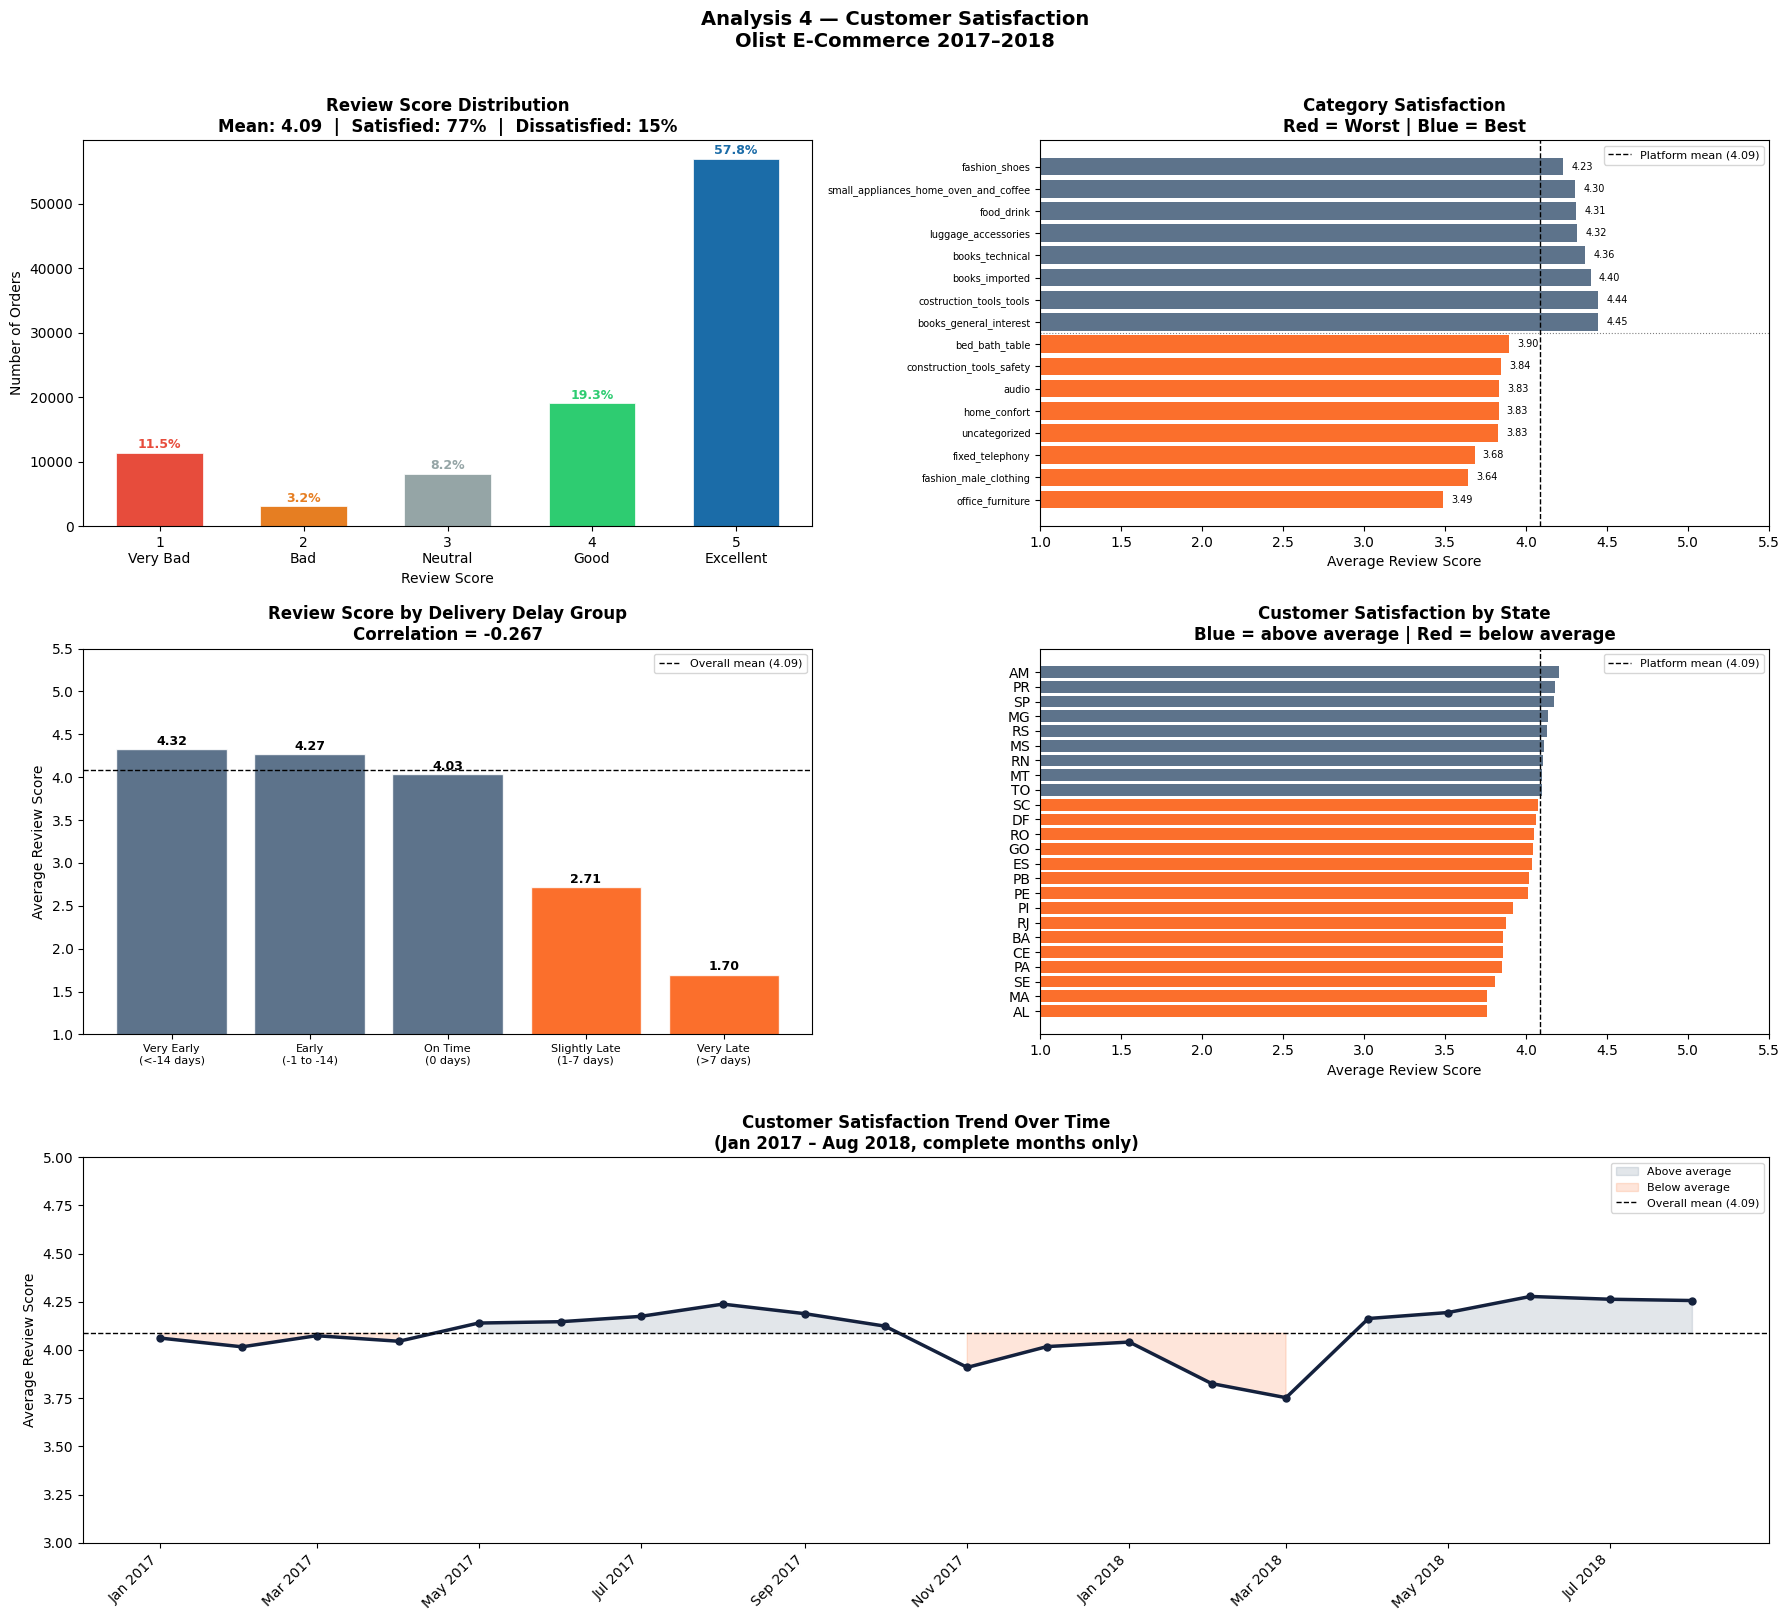

Saved to outputs/figures/04_customer_satisfaction.png


In [50]:
fig = plt.figure(figsize=(18, 16))

 
ax1 = fig.add_subplot(3, 2, 1)
 
bar_colours = {
    1: '#E74C3C',   # Red — very dissatisfied
    2: '#E67E22',   # Orange — dissatisfied
    3: '#95A5A6',   # Grey — neutral
    4: '#2ECC71',   # Light green — satisfied
    5: '#1B6CA8',   # Blue — very satisfied
}
 
bars = ax1.bar(
    score_counts.index,
    score_counts.values,
    color=[bar_colours[s] for s in score_counts.index],
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)
 
# Add percentage labels above each bar
for bar, (score, pct) in zip(bars, score_pcts.items()):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
        color=bar_colours[score]
    )
 
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Number of Orders')
ax1.set_title(
    f'Review Score Distribution\n'
    f'Mean: {mean_score:.2f}  |  '
    f'Satisfied: {satisfied:.0f}%  |  '
    f'Dissatisfied: {dissatisfied:.0f}%',
    fontweight='bold'
)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['1\nVery Bad', '2\nBad', '3\nNeutral', '4\nGood', '5\nExcellent'])
 

 
ax2 = fig.add_subplot(3, 2, 2)
 
n_show = 8
best  = category_stats.head(n_show)
worst = category_stats.tail(n_show).sort_values('avg_score')
 
# Combine into one chart with a visual gap
all_cats   = pd.concat([worst, best])
all_scores = all_cats['avg_score'].values
all_names  = all_cats['product_category_name_english'].values
colours    = (
    [COLOUR_HIGHLIGHT] * n_show +
    [COLOUR_ACCENT] * n_show
)
 
bars2 = ax2.barh(range(len(all_cats)), all_scores, color=colours, alpha=0.85)
 
ax2.set_yticks(range(len(all_cats)))
ax2.set_yticklabels(all_names, fontsize=7)
ax2.axvline(x=mean_score, color='black', linewidth=1,
            linestyle='--', label=f'Platform mean ({mean_score:.2f})')
ax2.axhline(y=n_show - 0.5, color='grey', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Average Review Score')
ax2.set_title('Category Satisfaction\nRed = Worst | Blue = Best', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim(1, 5.5)
 
# Score labels
for i, (bar, score) in enumerate(zip(bars2, all_scores)):
    ax2.text(
        score + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{score:.2f}',
        va='center', fontsize=7
    )

 
ax3 = fig.add_subplot(3, 2, 3)
 
bin_colours = [COLOUR_ACCENT] * len(delay_bin_stats)
 
# Colour late bins red
for i, label in enumerate(delay_bin_stats['delay_bin'].astype(str)):
    if 'Late' in label:
        bin_colours[i] = COLOUR_HIGHLIGHT
 
bars3 = ax3.bar(
    range(len(delay_bin_stats)),
    delay_bin_stats['avg_score'],
    color=bin_colours,
    alpha=0.85,
    edgecolor='white'
)
 
# Add score and order count labels
for i, (bar, row) in enumerate(zip(bars3, delay_bin_stats.itertuples())):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{row.avg_score:.2f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        0.2,
        f'n={row.order_count:,}',
        ha='center', va='bottom',
        fontsize=7, color='white'
    )
 
ax3.axhline(y=mean_score, color='black', linewidth=1,
            linestyle='--', label=f'Overall mean ({mean_score:.2f})')
ax3.set_xticks(range(len(delay_bin_stats)))
ax3.set_xticklabels(
    delay_bin_stats['delay_bin'].astype(str),
    fontsize=8
)
ax3.set_ylabel('Average Review Score')
ax3.set_ylim(1, 5.5)
ax3.set_title(
    f'Review Score by Delivery Delay Group\n'
    f'Correlation = {correlation:.3f}',
    fontweight='bold'
)
ax3.legend(fontsize=8)
 
# ── Chart 4: Satisfaction by state ────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
 
state_colours = [
    COLOUR_ACCENT if s >= mean_score else COLOUR_HIGHLIGHT
    for s in state_satisfaction['avg_score']
]
 
ax4.barh(
    state_satisfaction['customer_state'][::-1],
    state_satisfaction['avg_score'][::-1],
    color=state_colours[::-1],
    alpha=0.85
)
ax4.axvline(
    x=mean_score,
    color='black', linewidth=1,
    linestyle='--',
    label=f'Platform mean ({mean_score:.2f})'
)
ax4.set_xlabel('Average Review Score')
ax4.set_title(
    'Customer Satisfaction by State\n'
    'Blue = above average | Red = below average',
    fontweight='bold'
)
ax4.legend(fontsize=8)
ax4.set_xlim(1, 5.5)
 

ax5 = fig.add_subplot(3, 1, 3)

reviewed_orders['order_month'] = (
    reviewed_orders['order_purchase_timestamp'].dt.to_period('M')
)
monthly_satisfaction = (
    reviewed_orders
    .groupby('order_month')['review_score']
    .mean()
    .reset_index()
)
monthly_satisfaction['month_dt'] = (
    monthly_satisfaction['order_month'].dt.to_timestamp()
)
 
ax5.plot(
    monthly_satisfaction['month_dt'],
    monthly_satisfaction['review_score'],
    color=COLOUR_PRIMARY,
    linewidth=2.5,
    marker='o',
    markersize=5
)
ax5.fill_between(
    monthly_satisfaction['month_dt'],
    monthly_satisfaction['review_score'],
    mean_score,
    where=monthly_satisfaction['review_score'] >= mean_score,
    alpha=0.15,
    color=COLOUR_ACCENT,
    label='Above average'
)
ax5.fill_between(
    monthly_satisfaction['month_dt'],
    monthly_satisfaction['review_score'],
    mean_score,
    where=monthly_satisfaction['review_score'] < mean_score,
    alpha=0.15,
    color=COLOUR_HIGHLIGHT,
    label='Below average'
)
ax5.axhline(
    y=mean_score,
    color='black',
    linewidth=1,
    linestyle='--',
    label=f'Overall mean ({mean_score:.2f})'
)
 
import matplotlib.dates as mdates
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
 
ax5.set_ylabel('Average Review Score')
ax5.set_ylim(3, 5)
ax5.set_title(
    'Customer Satisfaction Trend Over Time\n'
    '(Jan 2017 – Aug 2018, complete months only)',
    fontweight='bold'
)
ax5.legend(fontsize=8)
 
plt.suptitle(
    'Analysis 4 — Customer Satisfaction\nOlist E-Commerce 2017–2018',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

plt.show()
print("Saved to outputs/figures/04_customer_satisfaction.png")
 

## Analysis 4 — Customer Satisfaction: Observations & Findings
 
---
 
### Finding 1 — Satisfaction Is Strongly Bimodal

The distribution of review scores is bimodal rather than regularly distributed, with the highest concentrations at five stars and one star. Globally, e-commerce reviews typically look like this: Customers are most like to submit a rating if they have great or bad experiences. Customers who are silent (no reviews) typically have a modest level of satisfaction.
 
- **Satisfied (4-5 stars):** 77% of reviewed orders
- **Neutral (3 stars):** 8%
- **Dissatisfied (1-2 stars):** 15%
- **Mean score:** 4.09 / 5.00


*Implication: A bimodal reality is concealed by the headline mean score.
A strategy that solely concentrates on raising the mean could overlook the unique factors that lead to 1-star results, which need for different interventions as opposed to encouraging 3-star clients to become 4-star.*
 
---
 
### Finding 2 — Category Satisfaction Varies By 4.09 Points
 
The gap between the highest and lowest rated product categories
is approximately 4.09 points on a 5-point scale
(from 4.45 to 3.49).
 
The worst performing categories (office_furniture , fashion_male_clothing, fixed_telephony ) are likely candidates for quality control review or seller
performance management.
 
The best performing categories (books_general_interest, costruction_tools_tools ,  books_imported  ) demonstrate that high satisfaction is achievable on the platform and
should be studied as models.
 
---
 
### Finding 3 — Delivery Delay Has A Measurable But Moderate Effect
 
The correlation between delivery_delay_days and review_score
is **-0.2669**  a weak negative relationship.
 
The delay bin analysis shows a clear pattern:
- Very early deliveries average 4.32  stars
- Very late deliveries average 1.70 stars
- The gap between best and worst delivery group: 4.09 points
 
This confirms that delivery delay hurts satisfaction but is not
the only driver , the gap is meaningful but leaves substantial
variance unexplained, suggesting product quality and seller
service also contribute significantly.
 
*Formally tested in Notebook 02, Hypothesis 1.*
 
---
 
### Finding 4 — Satisfaction Is Stable  Over Time
Customers were generally pretty satisfied. 
- **Early 2017 (Jan–Aug)** — Scores were stable and healthy, hovering right around the 4.1 mark. Nothing dramatic, just consistent performance.
- **Sep–Oct 2017** — A small peak, the best stretch of the whole year, reaching about 4.25+.
- **Nov 2017 – Apr 2018** — This is the trouble zone, highlighted in pink on the chart. Scores dropped below the overall average, bottoming out around 3.8 in March/April 2018 — the worst point in the entire dataset. Something clearly went wrong here, whether that's delivery problems, product quality issues, or seasonal demand the business wasn't ready for.
May 2018 onwards — A strong recovery. Scores bounced back above the average and actually climbed to their highest point ever by July/August 2018, finishing around 4.25–4.3.

 
---
⚠️ Notable Insight: The satisfaction dip in Nov 2017 – Mar 2018 coincides directly with the Black Friday revenue spike (+55% MoM). This suggests the volume surge outpaced operational capacity, negatively impacting customer experience. While the revenue gain was significant, the corresponding drop in satisfaction scores raises questions about the true long-term ROI of unmanaged demand spikes.
 
### Summary Table
 
| Metric | Value |
|--------|-------|
| Orders with review scores | 98 673 (99.2% coverage) |
| Mean review score | 4.09 / 5.00 |
| % Satisfied (4-5 stars) | 77.1% |
| % Dissatisfied (1-2 stars) | 14.7% |
| Delay-satisfaction correlation | -0.27 |
| Best category avg score | 4.45 — books_general_interest |
| Worst category avg score | 3.49 — office_furniture |
 
---
*Connects to: Notebook 02 Hypothesis 1 (delivery delay vs
review score statistical test) and Notebook 03 (review_score
used as a feature in churn prediction model).*
"""
 

## Analysis 5 — RFM Customer Segmentation
 
**Business question:** How can customers be meaningfully
segmented by their purchasing behaviour, and which segments
represent the most strategic value?
 
**Why RFM matters:** Not all customers are equal. Treating
a customer who has bought 8 times in the last month the
same as one who bought once two years ago wastes retention
budget and misses high-value opportunities. RFM gives every
customer a data-driven priority score built from behaviour,
not assumptions.

In [51]:
rfm = pd.read_csv('../data/processed/rfm_base.csv',
                  parse_dates=['first_order', 'last_order'])
 
print(f"RFM base shape: {rfm.shape}")
print(f"Unique customers: {len(rfm):,}")
print(f"\nCustomer frequency distribution:")
print(rfm['total_orders'].value_counts().head(10).to_string())
print(f"\nSpend distribution:")
print(rfm['total_spend'].describe().round(2).to_string())
print(f"\nRecency distribution (days since last order):")
print(rfm['recency_days'].describe().round(1).to_string())

RFM base shape: (96136, 10)
Unique customers: 96,136

Customer frequency distribution:
total_orders
1     93174
2      2714
3       200
4        29
5         8
6         6
7         3
9         1
17        1

Spend distribution:
count    96136.00
mean       166.52
std        231.36
min          0.00
25%         63.12
50%        108.00
75%        183.40
max      13664.08

Recency distribution (days since last order):
count    96136.0
mean       288.8
std        153.4
min          1.0
25%        164.0
50%        269.0
75%        398.0
max        773.0


In [52]:
rfm['R_score'] = pd.qcut(
    rfm['recency_days'],
    q=5,
    labels=[5, 4, 3, 2, 1],   # Reversed: recent = high score
    duplicates='drop'
)

In [53]:
rfm['F_score'] = pd.qcut(
    rfm['total_orders'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [54]:
rfm['M_score'] = pd.qcut(
    rfm['total_spend'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)
 

In [55]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [56]:
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
 
print("RFM scores assigned.")
print(f"\nRFM composite score distribution:")
print(rfm['RFM_score'].describe().round(1).to_string())
print(f"\nScore range: {rfm['RFM_score'].min()} to {rfm['RFM_score'].max()}")

RFM scores assigned.

RFM composite score distribution:
count    96136.0
mean         9.0
std          2.5
min          3.0
25%          7.0
50%          9.0
75%         11.0
max         15.0

Score range: 3 to 15


In [57]:
def assign_segment(row):
    score = row['RFM_score']
    r     = row['R_score']
    f     = row['F_score']
 
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and score >= 7:
        return 'At Risk'
    elif r <= 2 and score < 7:
        return 'Lost'
    else:
        return 'Potential Loyalists'
 
rfm['segment'] = rfm.apply(assign_segment, axis=1)

In [58]:
segment_profile = (
    rfm.groupby('segment')
    .agg(
        customer_count = ('customer_unique_id', 'count'),
        avg_recency    = ('recency_days', 'mean'),
        avg_frequency  = ('total_orders', 'mean'),
        avg_monetary   = ('total_spend', 'mean'),
        total_revenue  = ('total_spend', 'sum'),
        avg_rfm_score  = ('RFM_score', 'mean'),
    )
    .round(1)
    .reset_index()
)
 
total_customers = segment_profile['customer_count'].sum()
total_revenue   = segment_profile['total_revenue'].sum()
 
segment_profile['pct_customers'] = (
    segment_profile['customer_count'] / total_customers * 100
).round(1)
segment_profile['pct_revenue'] = (
    segment_profile['total_revenue'] / total_revenue * 100
).round(1)
 
# Sort by total revenue descending
segment_profile = segment_profile.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)
 
print("=" * 70)
print("  RFM SEGMENT PROFILES")
print("=" * 70)
print(f"{'Segment':<22} {'Customers':>9} {'% Cust':>7} "
      f"{'Avg Rec':>8} {'Avg Freq':>9} {'Avg Spend':>10} {'% Rev':>7}")
print("-" * 70)
for _, row in segment_profile.iterrows():
    print(f"  {row['segment']:<20} {row['customer_count']:>9,} "
          f"{row['pct_customers']:>6.1f}% "
          f"{row['avg_recency']:>7.0f}d "
          f"{row['avg_frequency']:>8.1f}x "
          f"R${row['avg_monetary']:>8,.0f} "
          f"{row['pct_revenue']:>6.1f}%")
 
# The key insight line
champ = segment_profile[segment_profile['segment'] == 'Champions']
if len(champ) > 0:
    print(f"\nKey insight: Champions are "
          f"{champ['pct_customers'].values[0]:.1f}% of customers "
          f"but generate {champ['pct_revenue'].values[0]:.1f}% of revenue")

  RFM SEGMENT PROFILES
Segment                Customers  % Cust  Avg Rec  Avg Freq  Avg Spend   % Rev
----------------------------------------------------------------------
  Loyal Customers         32,453   33.8%     226d      1.0x R$     216   43.9%
  At Risk                 18,642   19.4%     442d      1.0x R$     174   20.3%
  Champions                8,275    8.6%     143d      1.2x R$     339   17.5%
  Potential Loyalists     14,763   15.4%     248d      1.0x R$      90    8.3%
  Lost                    12,737   13.2%     467d      1.0x R$      70    5.5%
  New Customers            9,266    9.6%     148d      1.0x R$      78    4.5%

Key insight: Champions are 8.6% of customers but generate 17.5% of revenue


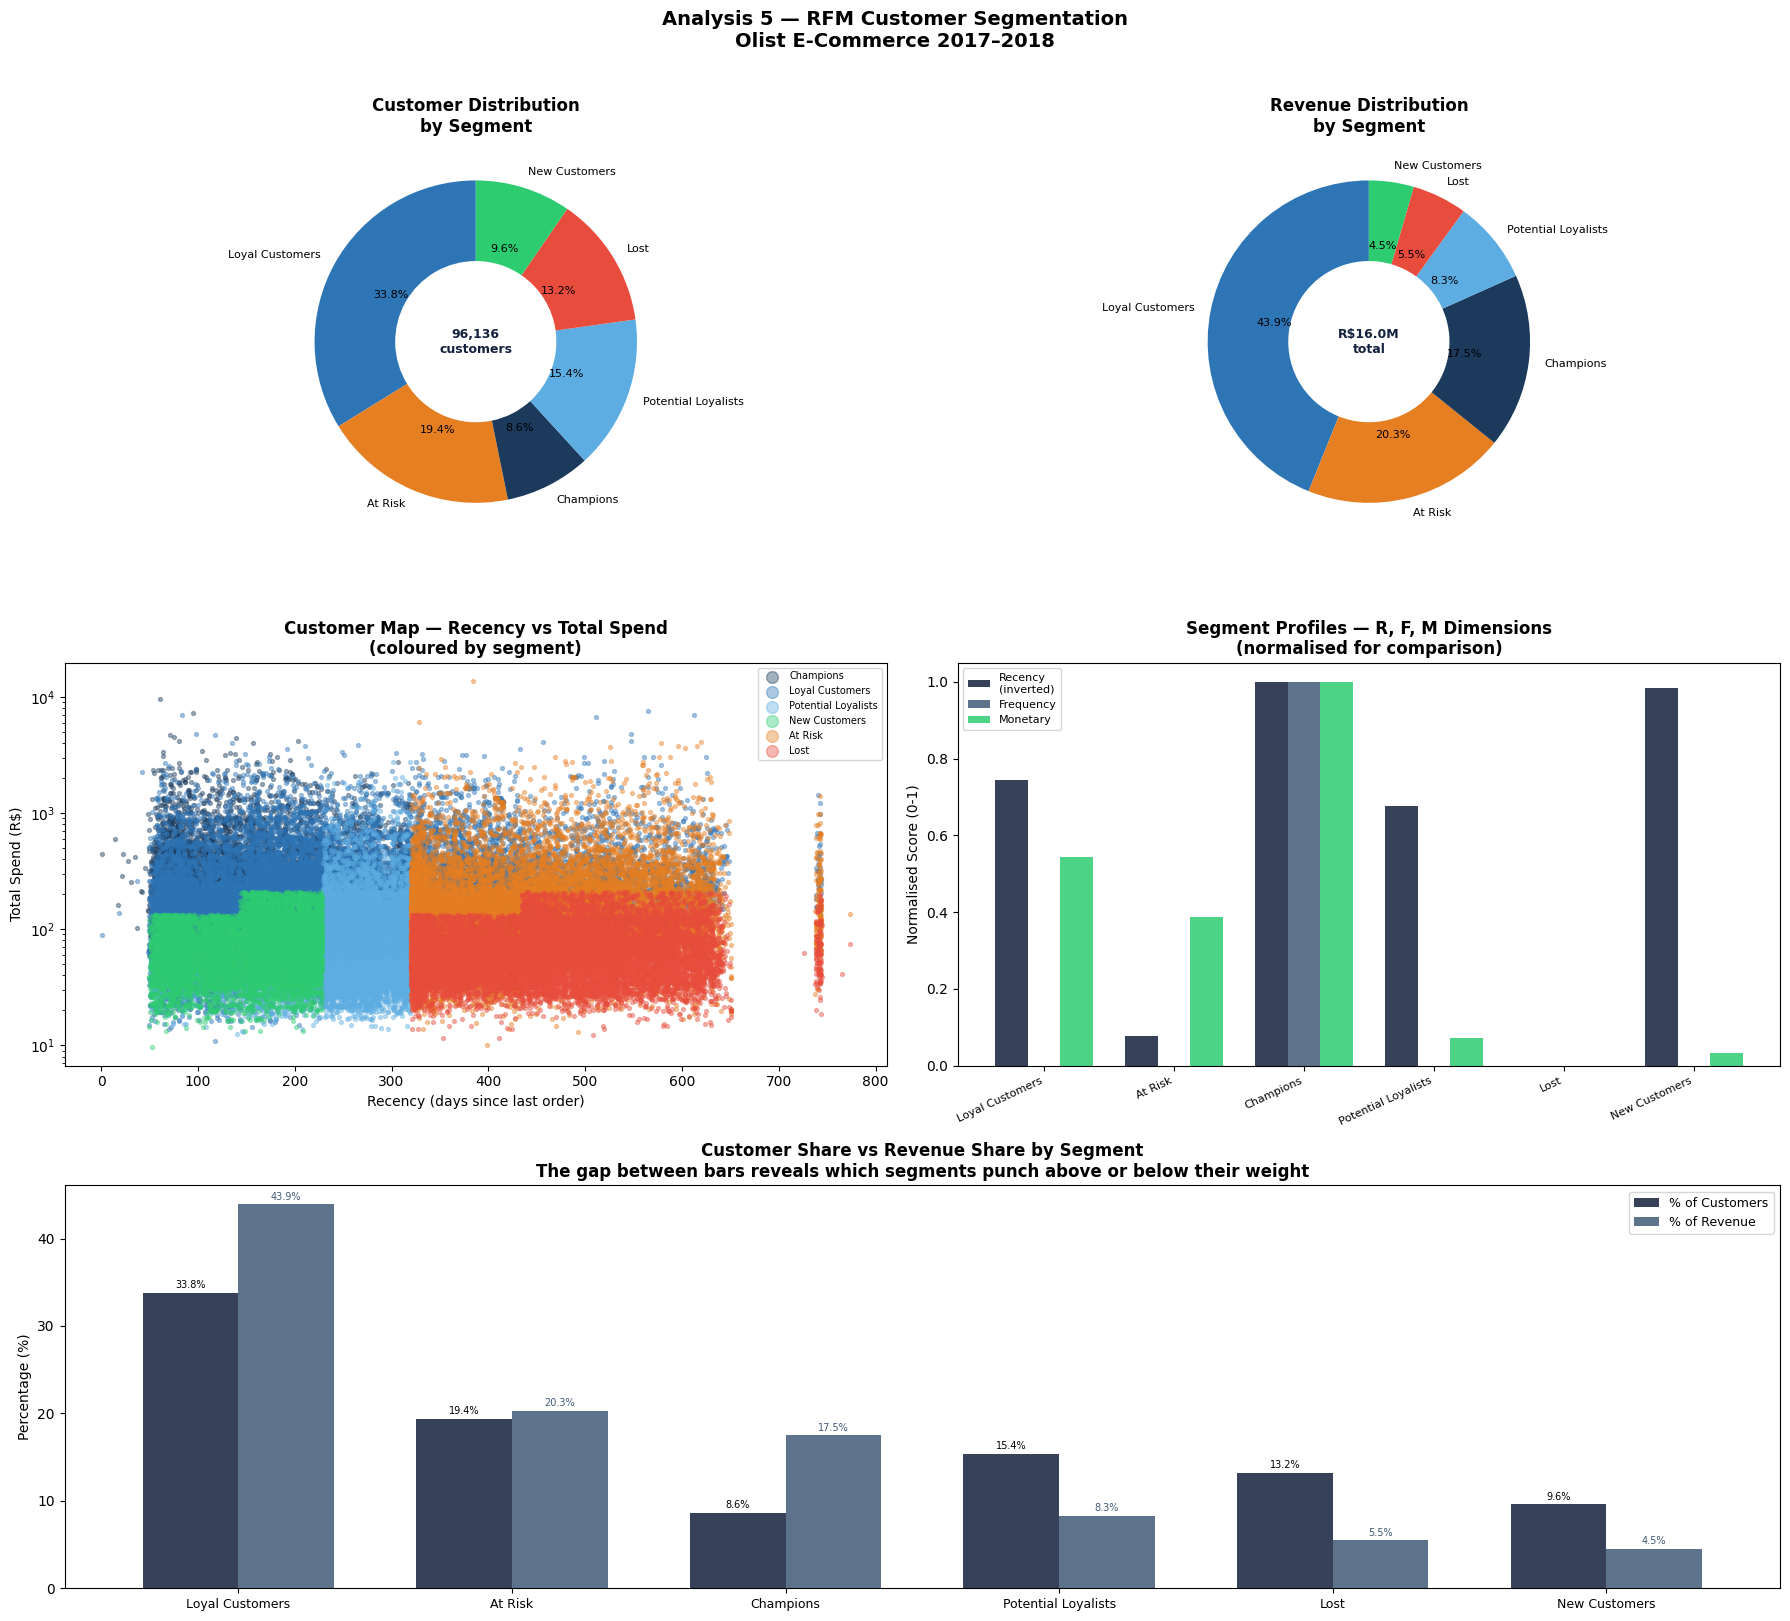

Saved to outputs/figures/05_rfm_segmentation.png


In [61]:
fig = plt.figure(figsize=(18, 16))
 
segment_colours = {
    'Champions':          '#1B3A5C',
    'Loyal Customers':    '#2E75B6',
    'Potential Loyalists':'#5DADE2',
    'New Customers':      '#2ECC71',
    'At Risk':            '#E67E22',
    'Lost':               '#E74C3C',
}
colours_list = [
    segment_colours.get(s, '#95A5A6')
    for s in segment_profile['segment']
]
 
# ── Chart 1: Customer count donut ─────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
 
wedges1, texts1, autotexts1 = ax1.pie(
    segment_profile['pct_customers'],
    labels=segment_profile['segment'],
    colors=colours_list,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops=dict(fontsize=8)
)
ax1.set_title('Customer Distribution\nby Segment', fontweight='bold')
ax1.text(0, 0, f'{total_customers:,}\ncustomers',
         ha='center', va='center',
         fontsize=9, fontweight='bold', color=COLOUR_PRIMARY)
 
# ── Chart 2: Revenue donut ─────────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
 
wedges2, texts2, autotexts2 = ax2.pie(
    segment_profile['pct_revenue'],
    labels=segment_profile['segment'],
    colors=colours_list,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops=dict(fontsize=8)
)
ax2.set_title('Revenue Distribution\nby Segment', fontweight='bold')
ax2.text(0, 0, f'R${total_revenue/1e6:.1f}M\ntotal',
         ha='center', va='center',
         fontsize=9, fontweight='bold', color=COLOUR_PRIMARY)
 
# ── Chart 3: RFM scatter plot ──────────────────────────────
# Recency vs Monetary coloured by segment
ax3 = fig.add_subplot(3, 2, 3)
 
for segment, colour in segment_colours.items():
    mask = rfm['segment'] == segment
    ax3.scatter(
        rfm.loc[mask, 'recency_days'],
        rfm.loc[mask, 'total_spend'],
        c=colour,
        label=segment,
        alpha=0.4,
        s=8
    )
 
ax3.set_xlabel('Recency (days since last order)')
ax3.set_ylabel('Total Spend (R$)')
ax3.set_title('Customer Map — Recency vs Total Spend\n(coloured by segment)',
              fontweight='bold')
ax3.legend(fontsize=7, markerscale=3)
ax3.set_yscale('log')   # Log scale because spend is heavily skewed
 
# ── Chart 4: Segment profile bar chart ────────────────────
# Normalise recency, frequency, monetary to 0-1 for comparison
ax4 = fig.add_subplot(3, 2, 4)
 
# Normalise each metric to 0-1 range
def normalise(series):
    return (series - series.min()) / (series.max() - series.min())
 
plot_data = segment_profile.set_index('segment')[
    ['avg_recency', 'avg_frequency', 'avg_monetary']
].copy()
 
# Invert recency — lower recency days = better, so invert for display
plot_data['avg_recency'] = 1 - normalise(plot_data['avg_recency'])
plot_data['avg_frequency'] = normalise(plot_data['avg_frequency'])
plot_data['avg_monetary'] = normalise(plot_data['avg_monetary'])
 
x = range(len(plot_data))
width = 0.25
 
ax4.bar([i - width for i in x], plot_data['avg_recency'],
        width=width, label='Recency\n(inverted)',
        color=COLOUR_PRIMARY, alpha=0.85)
ax4.bar(x, plot_data['avg_frequency'],
        width=width, label='Frequency',
        color=COLOUR_ACCENT, alpha=0.85)
ax4.bar([i + width for i in x], plot_data['avg_monetary'],
        width=width, label='Monetary',
        color='#2ECC71', alpha=0.85)
 
ax4.set_xticks(x)
ax4.set_xticklabels(plot_data.index, rotation=25, ha='right', fontsize=8)
ax4.set_ylabel('Normalised Score (0-1)')
ax4.set_title('Segment Profiles — R, F, M Dimensions\n(normalised for comparison)',
              fontweight='bold')
ax4.legend(fontsize=8)
 
# ── Chart 5: Customer vs Revenue share comparison ──────────
ax5 = fig.add_subplot(3, 1, 3)
 
segments_ordered = segment_profile['segment'].tolist()
x = range(len(segments_ordered))
width = 0.35
 
bars_cust = ax5.bar(
    [i - width/2 for i in x],
    segment_profile['pct_customers'],
    width=width,
    label='% of Customers',
    color=COLOUR_PRIMARY,
    alpha=0.85
)
bars_rev = ax5.bar(
    [i + width/2 for i in x],
    segment_profile['pct_revenue'],
    width=width,
    label='% of Revenue',
    color=COLOUR_ACCENT,
    alpha=0.85
)
 
# Add value labels
for bar in bars_cust:
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=7
    )
for bar in bars_rev:
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=7,
        color=COLOUR_ACCENT
    )
 
ax5.set_xticks(x)
ax5.set_xticklabels(segments_ordered, fontsize=9)
ax5.set_ylabel('Percentage (%)')
ax5.set_title(
    'Customer Share vs Revenue Share by Segment\n'
    'The gap between bars reveals which segments punch above or below their weight',
    fontweight='bold'
)
ax5.legend(fontsize=9)
 
plt.suptitle(
    'Analysis 5 — RFM Customer Segmentation\nOlist E-Commerce 2017–2018',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
rfm.to_csv('../data/processed/rfm_scored.csv', index=False)
plt.show()
print("Saved to outputs/figures/05_rfm_segmentation.png")

---
## Analysis 5 — RFM Segmentation: Observations & Findings
 
--- 
### Finding 1 — Champions Punch Far Above Their Weight
 
Champions represent **8.6% of customers** but generate
**17.5% of total revenue** — a 1.2x revenue multiplier
relative to their size.
 
This asymmetry is the central business insight from RFM
analysis. The disproportionate revenue contribution of a
small customer segment justifies disproportionate investment
in retaining them.
 
*Implication: A targeted Champions retention programme 
personalised outreach, loyalty rewards, priority customer
service — would protect a disproportionate share of revenue
at a relatively low cost per customer.*
 
---
 
### Finding 2 — The Lost Segment Is The Largest By Customer Count
 
**13.2% of customers are classified as Lost** , they have not
ordered recently, ordered infrequently, and spent relatively
little. This is not surprising for a growing marketplace
where many customers try the platform once and do not return.
 
The high proportion of one-time buyers is a structural
characteristic of marketplace e-commerce rather than a
failure specific to Olist. However, it raises the question
of whether any intervention during the first purchase
experience could convert first-time buyers into repeat ones.
 
*This becomes the churn prediction problem in Notebook 03:
what characteristics at the time of the first order predict
whether a customer will return?*
 
---
 
### Finding 3 — At Risk Customers Are The Highest Priority
 
At Risk customers were once valuable (moderate-to-high
frequency and monetary) but have not ordered recently.
They represent **recoverable revenue** , unlike Lost customers
who may never return, At Risk customers have demonstrated
intent and capacity to spend on the platform.
 
Average spend: R$216 (compare to Champions: R$339)
Average recency: 442 days (compare to Champions: 143 days)
 
*Implication: A win-back campaign targeting At Risk customers
specifically , a personalised discount, a reminder of past
purchases, early access to new products , could recover
revenue that is otherwise headed toward Lost status.*
 
---
 
### RFM Segment Summary Table
 
| Segment | Customers | % Customers | % Revenue | Avg Spend | Avg Recency |
|---------|-----------|-------------|-----------|-----------|-------------|
| Champions | 8 275 | 8.6% | 17.5% | R$339 | 143 days |
| Loyal Customers | 32 453 | 33.8% | 43.9% | R$216 | 226 days |
| Potential Loyalists | 14 763 | 15.4% | 8.3% | R$90 | 248 days |
| New Customers | 9 266 | 9.6% | 4.5% | R$78 | 148 days |
| At Risk | 18 642 | 19.4% | 20.3% | R$174 | 442 days |
| Lost | 12 737 | 13.2% | 5.5% | R$70 | 467 days |
 

 
---
*RFM segments feed directly into Notebook 03 where segment
membership becomes a feature in the churn prediction model.
The At Risk and Lost segments define the churn label.*


```
